In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix, classification_report,
                             precision_score, recall_score, fbeta_score,
                             matthews_corrcoef, roc_curve, roc_auc_score)
import warnings

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

Load dataset and normalize column names.
This cell loads the dataset from the CSV file and normalizes the column names by
removing leading and trailing whitespace and converting all letters to lowercase.

In [2]:
path = "C:\\Users\\idane\\PythonProjects\\GSAF_Matriz_ML.csv"
raw = pd.read_csv(path)
raw.columns = raw.columns.str.strip().str.lower()
display(raw.shape)

(5124, 37)

Column selection.
This cell builds the working dataframe from the columns used in this assignment,
converts the numeric columns to numbers, converts the month names to month numbers,
and replaces the 'unknown' placeholder with a missing value.

In [3]:
def to_number(col):
    return pd.to_numeric(raw[col].astype(str).str.strip().str.lower().replace('unknown', np.nan),
                         errors='coerce')

months = {m: i + 1 for i, m in enumerate(
    ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])}

def to_month(value):
    text = str(value).strip().lower()
    if text[:3] in months:
        return months[text[:3]]
    try:
        number = int(float(text))
        return number if 1 <= number <= 12 else np.nan
    except (ValueError, TypeError):
        return np.nan

df = pd.DataFrame()
df['year'] = to_number('year')
df['month'] = raw['month'].map(to_month)
df['day'] = to_number('day')
df['hour'] = to_number('hour')
df['shark_size_meters'] = to_number('shark_size_meters')

for col in ['country', 'state', 'species', 'time_of_day', 'activity_clean', 'moon_phase']:
    df[col] = raw[col].astype(str).str.strip().replace({'unknown': np.nan, 'Unknown': np.nan})

act_cols = [c for c in raw.columns if c.startswith('act_')]
lua_cols = [c for c in raw.columns if c.startswith('lua_')]
for col in act_cols + lua_cols:
    df[col] = pd.to_numeric(raw[col], errors='coerce')

df['country'] = df['country'].str.upper()
df['country'] = df['country'].where(df['country'].map(df['country'].value_counts()) >= 20, 'OTHER')
df['state'] = df['state'].where(df['state'].map(df['state'].value_counts()) >= 20, 'OTHER')
df['is_white_shark'] = (df['species'] == 'White Shark').astype(int)

display(df.shape)
display(df.dtypes)

(5124, 23)

year                   float64
month                    int64
day                    float64
hour                   float64
shark_size_meters      float64
country                    str
state                      str
species                    str
time_of_day                str
activity_clean             str
moon_phase                 str
act_diving               int64
act_fishing              int64
act_other                int64
act_surfing              int64
act_swimming             int64
act_unknown              int64
act_wading/standing      int64
lua_full moon            int64
lua_new moon             int64
lua_waning crescent      int64
lua_waxing crescent      int64
is_white_shark           int64
dtype: object

The two prediction problems.
The regression target is shark_size_meters, the estimated length of the shark in metres,
which is recorded for 1280 of the incidents. The classification target is is_white_shark,
which indicates whether the animal was identified as a White Shark, over the 3090 incidents
where the species was identified. This cell builds the two samples and describes the targets.

In [4]:
reg_df = df[df['shark_size_meters'].notna()].reset_index(drop=True)
clf_df = df[df['species'].notna()].reset_index(drop=True)

print('Regression sample:', len(reg_df), 'rows')
print('Classification sample:', len(clf_df), 'rows')
print('White Shark base rate:', round(clf_df['is_white_shark'].mean(), 3),
      '(', int(clf_df['is_white_shark'].sum()), 'positives )')

print('\nRegression target by species:')
display(reg_df.groupby('species')['shark_size_meters']
        .agg(['count', 'mean', 'std', 'min', 'median', 'max']).round(2))

print('Classification target:')
display(clf_df['species'].value_counts().rename('count').to_frame())

Regression sample: 1280 rows
Classification sample: 3090 rows
White Shark base rate: 0.22 ( 680 positives )

Regression target by species:


,count,mean,std,min,median,max
species,,,,,,
Bull Shark,73,2.33,0.74,1.0,2.13,4.0
Other,719,2.24,1.06,0.5,2.00,7.0
Tiger Shark,106,3.02,1.02,1.2,3.00,6.1
White Shark,374,4.00,1.26,1.0,4.00,7.6


Classification target:


,count
species,
Other,1918
White Shark,680
Tiger Shark,279
Bull Shark,213


Feature set.
All models are trained on the same features so that the comparison between them is fair.
The numeric features are the year, the month, the day, the hour, the seven act_ activity
indicators and the four lua_ lunar phase indicators. The categorical features are the country,
the state, the time of day, the activity and the moon phase.

The species is added to the regression features. It is the strongest predictor of the length
and it is recorded independently of the length itself, so it is not leakage. The species and
the shark length are both excluded from the classification features, the first because it is
the target and the second because it is missing for 75 percent of the rows.

The preprocessing fills the missing numeric values with the median and the missing categorical
values with the most frequent value, standardises the numeric features and one hot encodes the
categorical features. It is placed inside a pipeline so that it is fitted on the training folds
only and no information leaks from the test fold.

In [6]:
NUM_FEATURES = ['year', 'month', 'day', 'hour'] + act_cols + lua_cols
CAT_FEATURES = ['country', 'state', 'time_of_day', 'activity_clean', 'moon_phase']
REG_CAT = CAT_FEATURES + ['species']

def build_preprocessor(cat_features):
    return ColumnTransformer([
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), NUM_FEATURES),
        ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                                  ('encode', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ])

X_reg = reg_df[NUM_FEATURES + REG_CAT]
y_reg = reg_df['shark_size_meters'].to_numpy()
X_clf = clf_df[NUM_FEATURES + CAT_FEATURES]
y_clf = clf_df['is_white_shark'].to_numpy()

print('Regression features:', X_reg.shape, '->',
      build_preprocessor(REG_CAT).fit_transform(X_reg).shape[1], 'encoded columns')
print('Classification features:', X_clf.shape, '->',
      build_preprocessor(CAT_FEATURES).fit_transform(X_clf).shape[1], 'encoded columns')
print('\nMissing values in the features:')
display(X_reg.isna().sum()[lambda s: s > 0].rename('missing').to_frame().T)

Regression features: (1280, 21) -> 75 encoded columns
Classification features: (3090, 20) -> 71 encoded columns

Missing values in the features:


,day,hour,time_of_day,activity_clean,species
missing,51,513,415,24,8


Choice of k for the cross validation.
The assignment asks for the choice of k to be justified against the dataset size, the
computational complexity and the bias variance trade off. The value chosen here is k = 10.

Dataset size. The regression sample has 1280 rows and the classification sample has 3090 rows.
With k = 10 each training fold holds 90 percent of the data, so the models are fitted on 1152
and 2781 rows, close enough to the full sample that the cross validated score is a nearly
unbiased estimate of the score of a model trained on everything. With k = 5 the training folds
drop to 80 percent, which on a sample of this size introduces a visible pessimistic bias.

Bias variance trade off. A small k means small training sets and therefore a pessimistically
biased estimate of the error. A large k means training sets that overlap almost completely,
so the fold scores become highly correlated and the variance of the averaged estimate stops
falling, while the variance of each individual fold score rises because each test fold is
smaller. Leave one out is the extreme case, almost unbiased but with a high variance and a
computational cost of 1280 fits per model. k = 10 is the standard compromise between the two.

Test fold size. Each held out fold contains 128 regression rows and 309 classification rows,
of which about 68 are White Sharks. That is enough for a stable confusion matrix per fold.
At k = 20 a fold would hold only 34 positives and the threshold analysis of section 3.4 would
become unstable from fold to fold.

Computational complexity. Ten folds over six regression models take a few seconds, so the cost
is not the binding constraint and k can be chosen on statistical grounds.

The classification folds are stratified so that every fold carries the same 22 percent positive
rate. Every metric, residual, confusion matrix and plot in this notebook is computed from out
of fold predictions, which means that each observation is predicted exactly once by a model
that was not trained on it.

In [7]:
K_FOLDS = 10
kf_reg = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
kf_clf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print('k =', K_FOLDS)
print('Regression: train fold', int(len(reg_df) * (K_FOLDS - 1) / K_FOLDS),
      'rows, test fold', int(len(reg_df) / K_FOLDS), 'rows')
print('Classification: train fold', int(len(clf_df) * (K_FOLDS - 1) / K_FOLDS),
      'rows, test fold', int(len(clf_df) / K_FOLDS), 'rows')

fold_rates = [round(y_clf[test].mean(), 3) for _, test in kf_clf.split(X_clf, y_clf)]
print('Positive rate in each stratified fold:', fold_rates)

k = 10
Regression: train fold 1152 rows, test fold 128 rows
Classification: train fold 2781 rows, test fold 309 rows
Positive rate in each stratified fold: [np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22), np.float64(0.22)]


Fitting the regression models.
Section 1 of the assignment analyses the errors of the regression models and section 2
compares the models themselves, so the models have to exist before either section can be
written. This cell fits the six models of section 2 with 10 fold cross validation and stores
their out of fold predictions. The comparison between them and the discussion are in section
2, after the error analysis.

The six models are Linear Regression as the baseline, a Decision Tree with max_depth 6 and
min_samples_leaf 20, a Random Forest with 400 trees and min_samples_leaf 3, Gradient Boosting
with the scikit learn defaults, and the two optional bonus models, KNN with 15 neighbours and
SVR with an RBF kernel, C 3.0 and epsilon 0.1. The hyperparameters are fixed in advance and
are not tuned, so that the comparison measures the modelling assumptions rather than the size
of a search budget.

In [8]:
REG_MODELS = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=20,
                                           random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=400, min_samples_leaf=3,
                                           random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'KNN (k=15)': KNeighborsRegressor(n_neighbors=15),
    'SVR (RBF)': SVR(C=3.0, epsilon=0.1),
}

oof_pred = {}
rows = []
for name, model in REG_MODELS.items():
    pipeline = Pipeline([('prep', build_preprocessor(REG_CAT)), ('model', model)])
    pred = cross_val_predict(pipeline, X_reg, y_reg, cv=kf_reg)
    oof_pred[name] = pred
    rows.append({'Model': name,
                 'MSE': mean_squared_error(y_reg, pred),
                 'RMSE': mean_squared_error(y_reg, pred) ** 0.5,
                 'MAE': mean_absolute_error(y_reg, pred),
                 'R2': r2_score(y_reg, pred)})

reg_scores = pd.DataFrame(rows).set_index('Model').sort_values('RMSE')
baseline_rmse = mean_squared_error(y_reg, np.full_like(y_reg, y_reg.mean())) ** 0.5
BEST_MODEL = reg_scores.index[0]

print('Fitted', len(REG_MODELS), 'models with', K_FOLDS, 'fold cross validation on',
      len(reg_df), 'rows')
print('Out of fold predictions collected for:', ', '.join(oof_pred))
print('Lowest RMSE:', BEST_MODEL, '- used for the error analysis of section 1')

Fitted 6 models with 10 fold cross validation on 1280 rows
Out of fold predictions collected for: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, KNN (k=15), SVR (RBF)
Lowest RMSE: Gradient Boosting - used for the error analysis of section 1


1  Regression Error Analysis

The residual is defined as in the assignment, residual = y - y_hat, so a positive residual
means the model under predicted the length of the shark. All the residuals below are the out
of fold residuals of Gradient Boosting, which section 2 shows to be the best of the six models
on RMSE and R2.

1.1  Residual Analysis
This cell plots the residuals as a function of the predicted values and the distribution of
the residuals.

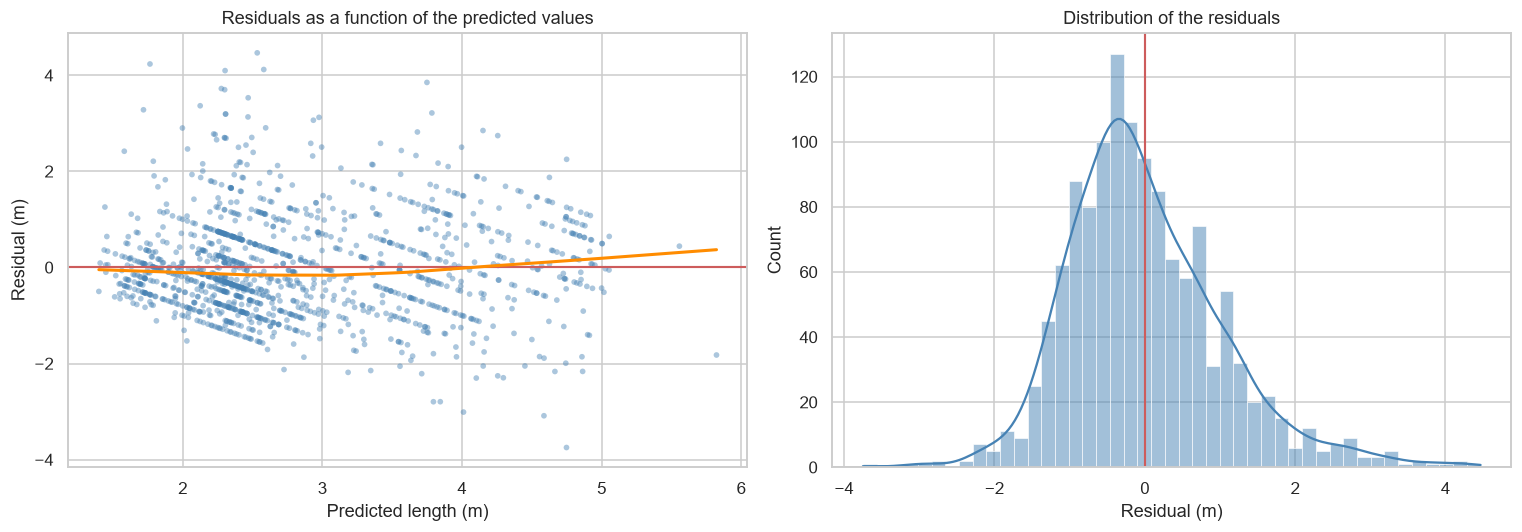

Model used for the error analysis: Gradient Boosting


,y_true,y_pred,residual,abs_error
count,1280.0000,1280.0000,1280.0000,1280.0000
mean,2.8248,2.8282,-0.0035,0.7883
std,1.3555,0.8880,1.0305,0.6633
min,0.5000,1.3996,-3.7488,0.0004
25%,1.8000,2.2404,-0.6871,0.3150
50%,2.5000,2.5273,-0.1658,0.6418
75%,3.7000,3.4579,0.5938,1.0937
max,7.6000,5.8232,4.4661,4.4661


In [9]:
err = reg_df.copy()
err['y_true'] = y_reg
err['y_pred'] = oof_pred[BEST_MODEL]
err['residual'] = err['y_true'] - err['y_pred']
err['abs_error'] = err['residual'].abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(err['y_pred'], err['residual'], s=14, alpha=0.45,
                color='steelblue', edgecolors='none')
axes[0].axhline(0, color='indianred', lw=1.4)
sns.regplot(x=err['y_pred'], y=err['residual'], lowess=True, scatter=False,
            ax=axes[0], line_kws=dict(color='darkorange', lw=2))
axes[0].set_xlabel('Predicted length (m)')
axes[0].set_ylabel('Residual (m)')
axes[0].set_title('Residuals as a function of the predicted values')

sns.histplot(err['residual'], bins=45, kde=True, ax=axes[1], color='steelblue',
             edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='indianred', lw=1.4)
axes[1].set_xlabel('Residual (m)')
axes[1].set_title('Distribution of the residuals')

plt.tight_layout()
plt.show()

print('Model used for the error analysis:', BEST_MODEL)
display(err[['y_true', 'y_pred', 'residual', 'abs_error']].describe().round(4))

This cell computes the statistics that answer the questions of section 1.1: whether the
residuals are centred on zero, whether their mean and spread change with the prediction,
and whether the variance is constant.

Mean residual: -0.00345 m
t test that the mean is zero: t = -0.12 , p = 0.9046
Spearman correlation between the absolute residual and the prediction: 0.228 , p = 1.57e-16
Slope of the predicted on the observed: 0.426 ( 1.0 would mean no shrinkage )

Residuals by decile of the prediction:


,centre,mean_residual,std_residual,n
y_pred,,,,
"(1.399, 1.83]",1.681,0.015,0.742,128
"(1.83, 2.142]",2.006,-0.060,0.825,128
"(2.142, 2.295]",2.231,0.106,0.937,128
"(2.295, 2.386]",2.335,0.106,1.082,128
"(2.386, 2.527]",2.446,-0.056,1.035,128
"(2.527, 2.76]",2.628,-0.035,1.126,128
"(2.76, 3.163]",2.924,-0.016,1.017,128
"(3.163, 3.706]",3.455,-0.135,1.102,128
"(3.706, 4.177]",3.918,-0.000,1.267,128


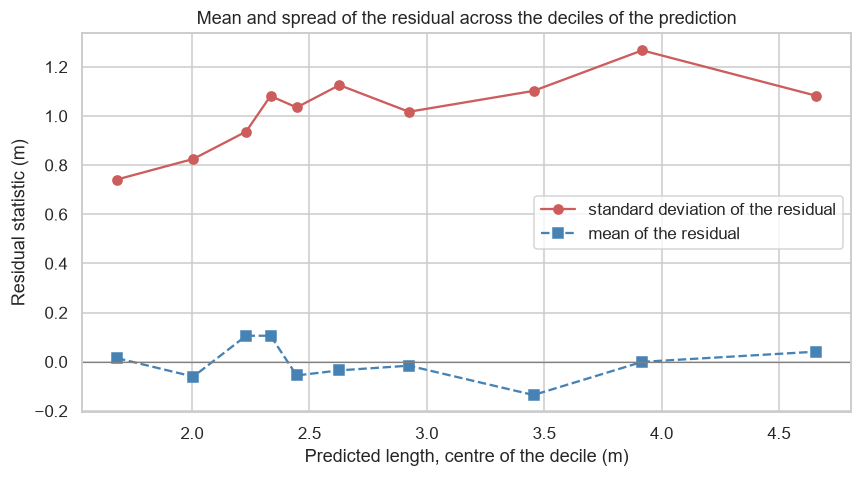

In [10]:
residual = err['residual'].to_numpy()
predicted = err['y_pred'].to_numpy()

t_stat, t_p = stats.ttest_1samp(residual, 0.0)
spearman_rho, spearman_p = stats.spearmanr(np.abs(residual), predicted)
slope = np.polyfit(err['y_true'], err['y_pred'], 1)[0]

print('Mean residual:', round(residual.mean(), 5), 'm')
print('t test that the mean is zero: t =', round(t_stat, 3), ', p =', round(t_p, 4))
print('Spearman correlation between the absolute residual and the prediction:',
      round(spearman_rho, 3), ', p =', format(spearman_p, '.2e'))
print('Slope of the predicted on the observed:', round(slope, 3),
      '( 1.0 would mean no shrinkage )')

deciles = err.groupby(pd.qcut(err['y_pred'], 10, duplicates='drop'), observed=True).agg(
    centre=('y_pred', 'mean'), mean_residual=('residual', 'mean'),
    std_residual=('residual', 'std'), n=('residual', 'size'))

print('\nResiduals by decile of the prediction:')
display(deciles.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(deciles['centre'], deciles['std_residual'], 'o-', color='indianred',
        label='standard deviation of the residual')
ax.plot(deciles['centre'], deciles['mean_residual'], 's--', color='steelblue',
        label='mean of the residual')
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Predicted length, centre of the decile (m)')
ax.set_ylabel('Residual statistic (m)')
ax.set_title('Mean and spread of the residual across the deciles of the prediction')
ax.legend()
plt.tight_layout()
plt.show()

Answers to the questions of section 1.1

Are the residuals centred around zero.
Approximately, in aggregate. The mean out of fold residual is -0.004 metres, which is very close to zero but not exactly zero, and the t test does not reject the hypothesis that it is zero. They are not centred conditionally, however: the table of deciles shows the mean residual moving between -0.14 and +0.11 across the range of the prediction. The model is globally approximately unbiased and locally biased.

Do the residuals exhibit any systematic patterns.
Two. The first is regression to the mean: the slope of the predicted on the observed length is 0.426 rather than 1.0, so the predictions are compressed towards the centre of the range. Any estimator of a conditional mean must shrink in this way when the features explain only part of the variance, so this is not a defect that tuning would remove. The second is a set of faint diagonal stripes in the scatter plot, which appear because the recorded lengths concentrate on whole and half metres. Every observation recorded as exactly 3.0 metres lies on the line residual = 3.0 - prediction.

Is there evidence of heteroscedasticity.
Yes. The standard deviation of the residual rises from 0.75 metres in the lowest decile of the prediction to between 1.1 and 1.3 in the top three, and the Spearman correlation between the absolute residual and the prediction is 0.228 with a p value below 1e-15. The variance is therefore not constant, so the standard errors and confidence intervals of an ordinary least squares fit are not valid on this data without a robust covariance estimator.

Is there a sector that is more likely to have high error rates.
Yes, and it is defined by the target rather than by any feature. The mean absolute error is 0.50 metres for sharks between 1.5 and 2.5 metres and 1.50 metres for sharks above 4.5 metres, and the bias runs from -0.93 to +1.49 metres over the same range. Section 1.2 shows that every other grouping which looks like an independent effect is a reflection of this one.

1.2  Error as a Function of Features
This cell plots the feature values against the residuals, which shows where the model is
systematically biased.

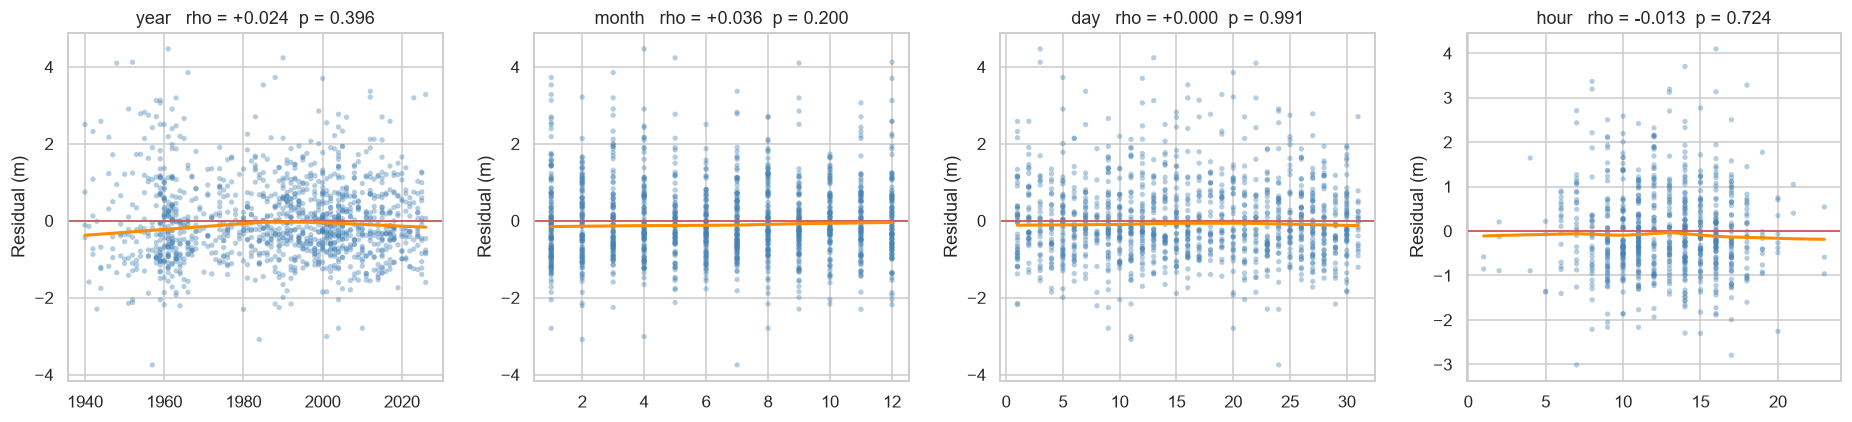

In [11]:
FEATURES_TO_PLOT = ['year', 'month', 'day', 'hour']

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, feature in zip(axes, FEATURES_TO_PLOT):
    sub = err[[feature, 'residual']].dropna()
    ax.scatter(sub[feature], sub['residual'], s=12, alpha=0.4,
               color='steelblue', edgecolors='none')
    ax.axhline(0, color='indianred', lw=1.2)
    sns.regplot(x=sub[feature], y=sub['residual'], lowess=True, scatter=False,
                ax=ax, line_kws=dict(color='darkorange', lw=2))
    rho, p = stats.spearmanr(sub[feature], sub['residual'])
    ax.set_title(feature + '   rho = ' + format(rho, '+.3f') + '  p = ' + format(p, '.3f'))
    ax.set_xlabel('')
    ax.set_ylabel('Residual (m)')

plt.tight_layout()
plt.show()

This cell plots the feature values against the absolute errors, which shows where the model
is imprecise regardless of the direction of the error.

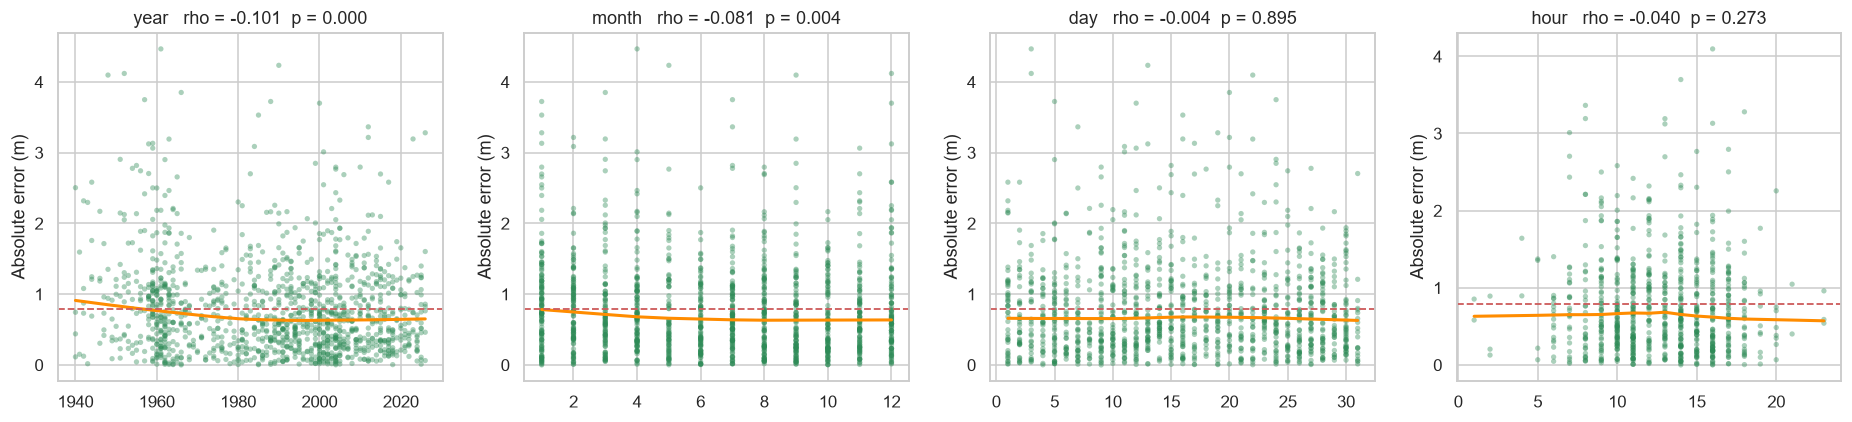

,n,rho with residual,p,rho with absolute error,p
feature,,,,,
year,1280,0.0238,0.3957,-0.1013,0.0003
month,1280,0.0359,0.1996,-0.0815,0.0035
day,1229,0.0003,0.9912,-0.0038,0.8947
hour,767,-0.0128,0.7244,-0.0396,0.2730


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, feature in zip(axes, FEATURES_TO_PLOT):
    sub = err[[feature, 'abs_error']].dropna()
    ax.scatter(sub[feature], sub['abs_error'], s=12, alpha=0.4,
               color='seagreen', edgecolors='none')
    sns.regplot(x=sub[feature], y=sub['abs_error'], lowess=True, scatter=False,
                ax=ax, line_kws=dict(color='darkorange', lw=2))
    ax.axhline(err['abs_error'].mean(), color='indianred', ls='--', lw=1.2)
    rho, p = stats.spearmanr(sub[feature], sub['abs_error'])
    ax.set_title(feature + '   rho = ' + format(rho, '+.3f') + '  p = ' + format(p, '.3f'))
    ax.set_xlabel('')
    ax.set_ylabel('Absolute error (m)')

plt.tight_layout()
plt.show()

rows = []
for feature in FEATURES_TO_PLOT:
    sub = err[[feature, 'residual', 'abs_error']].dropna()
    r_rho, r_p = stats.spearmanr(sub[feature], sub['residual'])
    a_rho, a_p = stats.spearmanr(sub[feature], sub['abs_error'])
    rows.append({'feature': feature, 'n': len(sub),
                 'rho with residual': r_rho, 'p': r_p,
                 'rho with absolute error': a_rho, 'p ': a_p})
display(pd.DataFrame(rows).set_index('feature').round(4))

This cell reports the bias and the absolute error inside the groups of the categorical
features and of the true length, which is where the subpopulations with a high error rate
appear.

In [13]:
err['size_band'] = pd.cut(err['y_true'], [0, 1.5, 2.5, 3.5, 4.5, 8],
                          labels=['under 1.5 m', '1.5 to 2.5 m', '2.5 to 3.5 m',
                                  '3.5 to 4.5 m', 'over 4.5 m'])

def error_by_group(key, min_n=20):
    table = err.groupby(key, observed=True).agg(
        n=('abs_error', 'size'),
        mean_true=('y_true', 'mean'),
        bias=('residual', 'mean'),
        MAE=('abs_error', 'mean'),
        RMSE=('residual', lambda s: float(np.sqrt((s ** 2).mean()))))
    return table[table['n'] >= min_n].sort_values('MAE', ascending=False)

for key in ['size_band', 'species', 'activity_clean', 'country', 'time_of_day']:
    print('Error by', key)
    display(error_by_group(key).round(3))

Error by size_band


,n,mean_true,bias,MAE,RMSE
size_band,,,,,
over 4.5 m,169,5.396,1.488,1.500,1.808
under 1.5 m,245,1.279,-0.930,0.931,1.067
3.5 to 4.5 m,169,4.046,0.677,0.864,1.052
2.5 to 3.5 m,268,3.064,0.108,0.616,0.736
1.5 to 2.5 m,429,2.065,-0.400,0.504,0.673


Error by species


,n,mean_true,bias,MAE,RMSE
species,,,,,
White Shark,374,4.003,0.018,0.875,1.112
Tiger Shark,106,3.016,0.056,0.841,1.013
Other,719,2.243,-0.021,0.749,1.011
Bull Shark,73,2.331,-0.022,0.623,0.745


Error by activity_clean


,n,mean_true,bias,MAE,RMSE
activity_clean,,,,,
Fishing,325,2.851,0.048,0.886,1.160
Other,251,3.030,0.045,0.847,1.072
Swimming,173,2.506,-0.057,0.807,1.064
Diving,37,2.671,-0.101,0.728,0.948
Surfing,426,2.936,-0.025,0.704,0.922
Wading/Standing,44,1.822,-0.165,0.558,0.744


Error by country


,n,mean_true,bias,MAE,RMSE
country,,,,,
OTHER,104,2.659,-0.009,0.928,1.163
NEW ZEALAND,36,3.188,0.100,0.916,1.143
AUSTRALIA,377,2.982,0.027,0.842,1.082
SOUTH AFRICA,229,2.733,-0.044,0.773,1.008
BAHAMAS,20,1.946,-0.263,0.703,0.961
USA,385,2.747,-0.031,0.675,0.916


Error by time_of_day


,n,mean_true,bias,MAE,RMSE
time_of_day,,,,,
Night,20,2.522,-0.228,1.020,1.204
Afternoon,447,2.870,0.000,0.763,0.986
Morning,345,2.936,-0.037,0.732,0.942
Evening,53,2.515,0.018,0.707,0.955


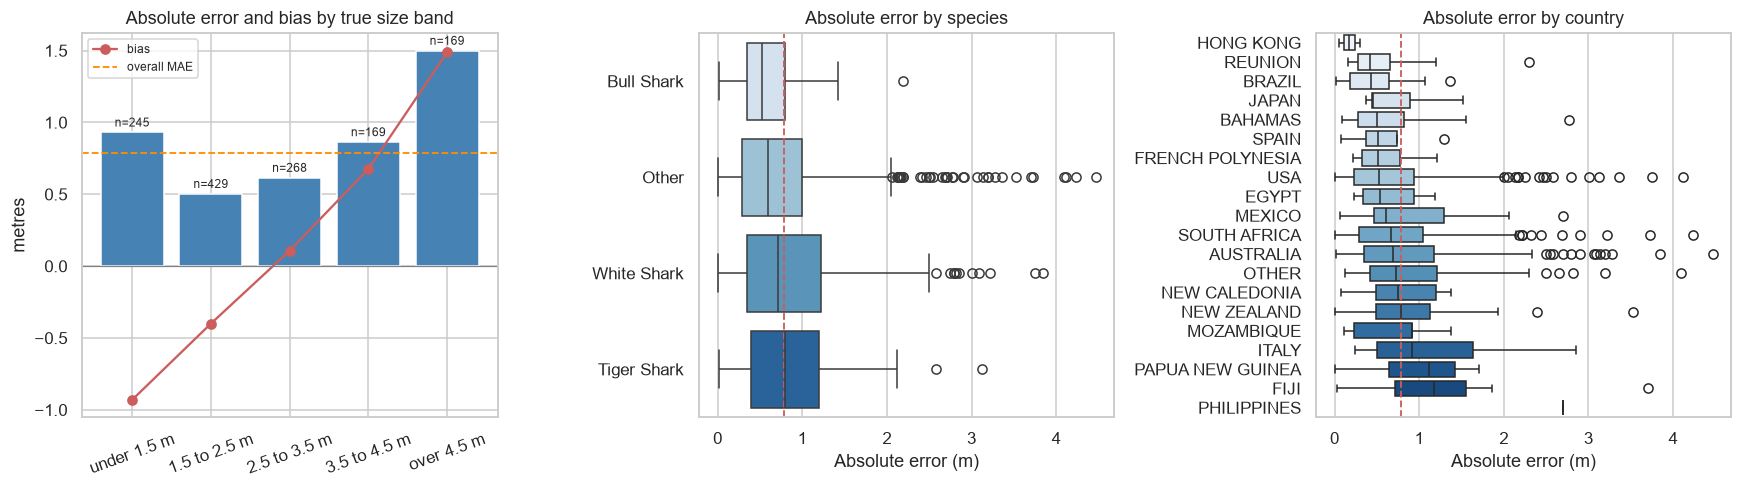

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

group = err.groupby('size_band', observed=True).agg(
    MAE=('abs_error', 'mean'), bias=('residual', 'mean'), n=('abs_error', 'size'))
axes[0].bar(range(len(group)), group['MAE'], color='steelblue', edgecolor='white')
axes[0].plot(range(len(group)), group['bias'], 'o-', color='indianred', label='bias')
axes[0].axhline(0, color='grey', lw=0.8)
axes[0].axhline(err['abs_error'].mean(), color='darkorange', ls='--', lw=1.2, label='overall MAE')
for i, (m, n) in enumerate(zip(group['MAE'], group['n'])):
    axes[0].text(i, m + 0.04, 'n=' + str(n), ha='center', fontsize=8)
axes[0].set_xticks(range(len(group)))
axes[0].set_xticklabels(group.index, rotation=20)
axes[0].set_ylabel('metres')
axes[0].set_title('Absolute error and bias by true size band')
axes[0].legend(fontsize=8)

species_order = err.groupby('species')['abs_error'].median().sort_values().index
sns.boxplot(data=err, x='abs_error', y='species', order=species_order,
            ax=axes[1], palette='Blues')
axes[1].axvline(err['abs_error'].mean(), color='indianred', ls='--', lw=1.2)
axes[1].set_xlabel('Absolute error (m)')
axes[1].set_ylabel('')
axes[1].set_title('Absolute error by species')

country_order = err.groupby('country')['abs_error'].median().sort_values().index
sns.boxplot(data=err, x='abs_error', y='country', order=country_order,
            ax=axes[2], palette='Blues')
axes[2].axvline(err['abs_error'].mean(), color='indianred', ls='--', lw=1.2)
axes[2].set_xlabel('Absolute error (m)')
axes[2].set_ylabel('')
axes[2].set_title('Absolute error by country')

plt.tight_layout()
plt.show()

What section 1.2 shows

Feature dependent error patterns.
None of the four numeric features has a rank correlation with the residual that differs
significantly from zero, so the model carries no directional bias with respect to the time of
the incident. The absolute error behaves differently: it falls significantly with the year, at
-0.101, and with the month, at -0.081. The year effect is the meaningful one, and section 1.3
shows that it is one of only two things separating the extreme errors from the rest.

Non linear relationships.
The LOWESS curves stay close to the zero line in every panel, so there is no strong curvature
against any numeric feature. The non linearity in this problem lies in the interaction between
the species and the location, which a plot against a single feature cannot show and which is
why the tree based models outperform the linear one.

Hidden subpopulations.
The band of the true length dominates everything else. The mean absolute error runs from 0.50
metres for sharks between 1.5 and 2.5 metres to 1.50 metres above 4.5 metres, and the bias from
-0.93 to +1.49 over the same range.

The species matters far less, and it is unbiased. The absolute error varies from 0.63 metres
for the Bull Shark to 0.87 for the White Shark, but the bias is essentially zero for every
species including the catch all Other category. The model places each species correctly on
average, and Other is harder only because it contains the larger and more variable animals.

The activity and the country show small differences that are again downstream of the size.
Fishing and the Other activity carry the highest error and also encounter the largest sharks;
Australia has the worst country level error and the largest mean recorded length, the United
States the best and the smallest. Night is the worst time of day group at 1.02 metres, but it
holds only 20 observations and the correlation between the hour and the absolute error is not
significant, so it is a caution rather than a finding.

1.3  Analysis of Extreme Errors
This cell identifies the top 5 percent largest absolute errors.

In [15]:
threshold = err['abs_error'].quantile(0.95)
err['is_extreme'] = err['abs_error'] >= threshold
extreme = err[err['is_extreme']].sort_values('abs_error', ascending=False)
rest = err[~err['is_extreme']]

print('95th percentile of the absolute error:', round(threshold, 3), 'm')
print('Extreme observations:', len(extreme), 'of', len(err),
      '(', round(100 * len(extreme) / len(err), 1), '% )')
print('Mean absolute error inside the extreme group:', round(extreme['abs_error'].mean(), 3), 'm')
print('Mean absolute error in the rest of the sample:', round(rest['abs_error'].mean(), 3), 'm')
print('Share of the total squared error carried by the top 5 percent:',
      round(100 * (extreme['residual'] ** 2).sum() / (err['residual'] ** 2).sum(), 1), '%')
print('Direction:', int((extreme['residual'] > 0).sum()), 'under predictions and',
      int((extreme['residual'] < 0).sum()), 'over predictions')

95th percentile of the absolute error: 2.116 m
Extreme observations: 64 of 1280 ( 5.0 % )
Mean absolute error inside the extreme group: 2.767 m
Mean absolute error in the rest of the sample: 0.684 m
Share of the total squared error carried by the top 5 percent: 37.7 %
Direction: 50 under predictions and 14 over predictions


This cell analyses the extreme observations individually. It lists the largest errors with
their recorded details, and it compares the extreme group against the rest of the sample on
every feature so that the cause can be identified.

In [16]:
columns = ['y_true', 'y_pred', 'residual', 'abs_error', 'species', 'country', 'state',
           'activity_clean', 'time_of_day', 'year', 'hour']
print('The 25 largest individual errors:')
display(extreme[columns].head(25)
        .rename(columns={'y_true': 'observed (m)', 'y_pred': 'predicted (m)',
                         'residual': 'residual (m)', 'abs_error': 'abs error (m)'})
        .round(2).reset_index(drop=True))

rows = []
for feature in ['y_true', 'year', 'month', 'day', 'hour', 'y_pred']:
    a = extreme[feature].dropna()
    b = rest[feature].dropna()
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                     / (len(a) + len(b) - 2))
    rows.append({'feature': feature, 'extreme mean': a.mean(), 'rest mean': b.mean(),
                 'Cohen d': (a.mean() - b.mean()) / pooled,
                 'Mann Whitney p': stats.mannwhitneyu(a, b)[1]})
comparison = pd.DataFrame(rows).set_index('feature')
comparison = comparison.reindex(comparison['Cohen d'].abs().sort_values(ascending=False).index)
print('What separates the extreme group from the rest:')
display(comparison.round(4))

composition = pd.DataFrame({
    'extreme %': extreme['species'].value_counts(normalize=True).mul(100),
    'whole sample %': err['species'].value_counts(normalize=True).mul(100)}).fillna(0)
composition['lift'] = composition['extreme %'] / composition['whole sample %']
print('Species composition of the extreme group:')
display(composition.round(2))

rounded = int((np.abs(extreme['y_true'] * 2 - np.round(extreme['y_true'] * 2)) < 1e-9).sum())
print('Extreme observations recorded at a whole or half metre:', rounded, 'of', len(extreme))

The 25 largest individual errors:


,observed (m),predicted (m),residual (m),abs error (m),species,country,state,activity_clean,time_of_day,year,hour
0,7.00,2.53,4.47,4.47,Other,AUSTRALIA,Victoria,Fishing,NaN,1961.0,NaN
1,6.00,1.77,4.23,4.23,Other,SOUTH AFRICA,KwaZulu-Natal,Fishing,NaN,1990.0,NaN
2,6.70,2.58,4.12,4.12,Other,USA,Hawaii,Swimming,NaN,1952.0,NaN
3,6.40,2.30,4.10,4.10,Other,OTHER,OTHER,Swimming,Afternoon,1948.0,16.0
4,7.60,3.75,3.85,3.85,White Shark,AUSTRALIA,New South Wales,Fishing,NaN,1966.0,NaN
5,1.00,4.75,-3.75,3.75,White Shark,USA,California,Fishing,NaN,1957.0,NaN
6,6.00,2.28,3.72,3.72,Other,SOUTH AFRICA,Western Cape Province,Other,NaN,1988.0,NaN
7,6.00,2.30,3.70,3.70,Other,FIJI,OTHER,Swimming,Afternoon,2000.0,14.0
8,6.00,2.47,3.53,3.53,Other,NEW ZEALAND,South Island,Other,NaN,1985.0,NaN
9,5.49,2.13,3.36,3.36,Other,USA,California,Other,Morning,2012.0,8.0


What separates the extreme group from the rest:


,extreme mean,rest mean,Cohen d,Mann Whitney p
feature,,,,
y_true,4.6827,2.7270,1.5193,0.0000
year,1976.6250,1989.3627,-0.5891,0.0000
y_pred,3.0186,2.8182,0.2259,0.0584
hour,12.0909,12.6689,-0.1643,0.2832
day,14.6230,15.9469,-0.1492,0.2574
month,6.0000,6.4260,-0.1209,0.3585


Species composition of the extreme group:


,extreme %,whole sample %,lift
species,,,
Other,55.56,56.53,0.98
White Shark,38.10,29.40,1.30
Tiger Shark,4.76,8.33,0.57
Bull Shark,1.59,5.74,0.28


Extreme observations recorded at a whole or half metre: 42 of 64


This cell plots the extreme errors against the rest of the sample.

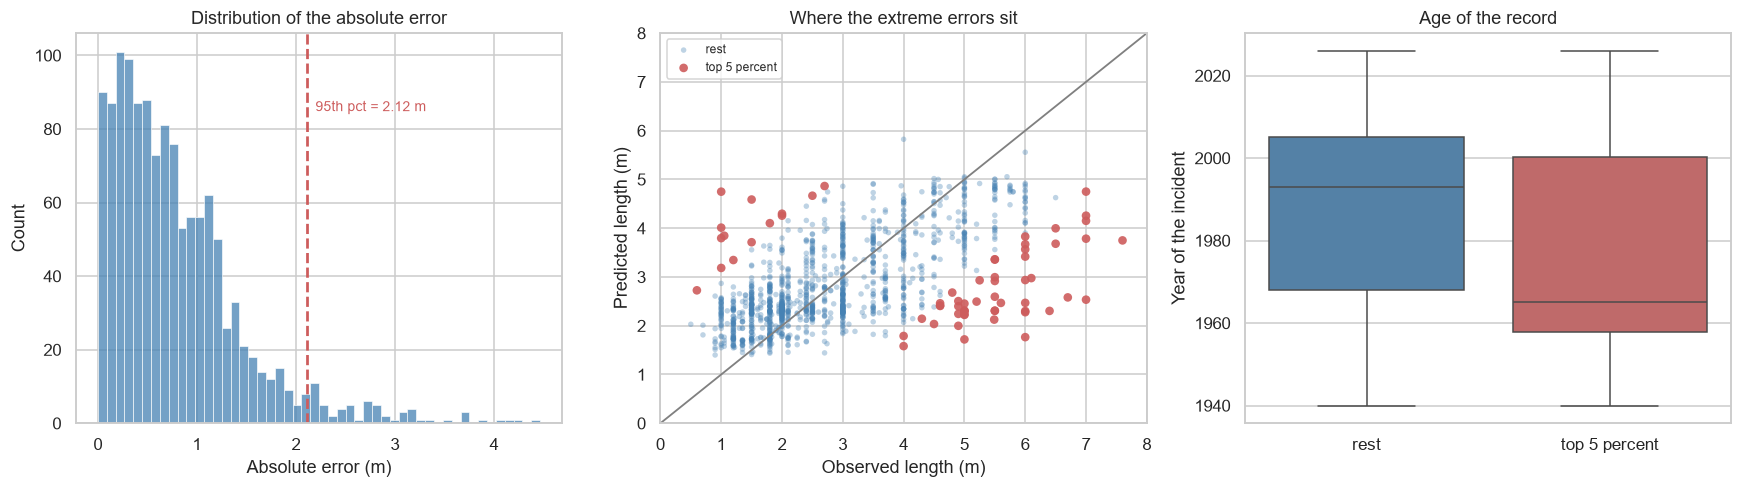

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sns.histplot(err['abs_error'], bins=50, ax=axes[0], color='steelblue',
             edgecolor='white', linewidth=0.4)
axes[0].axvline(threshold, color='indianred', lw=1.8, ls='--')
axes[0].text(threshold, axes[0].get_ylim()[1] * 0.8,
             '  95th pct = ' + format(threshold, '.2f') + ' m', color='indianred', fontsize=9)
axes[0].set_xlabel('Absolute error (m)')
axes[0].set_title('Distribution of the absolute error')

axes[1].scatter(rest['y_true'], rest['y_pred'], s=13, alpha=0.35,
                color='steelblue', label='rest', edgecolors='none')
axes[1].scatter(extreme['y_true'], extreme['y_pred'], s=32, alpha=0.9,
                color='indianred', label='top 5 percent', edgecolors='none')
axes[1].plot([0, 8], [0, 8], color='grey', lw=1.2)
axes[1].set_xlim(0, 8)
axes[1].set_ylim(0, 8)
axes[1].set_xlabel('Observed length (m)')
axes[1].set_ylabel('Predicted length (m)')
axes[1].set_title('Where the extreme errors sit')
axes[1].legend(fontsize=8)

sns.boxplot(data=err.assign(group=np.where(err['is_extreme'], 'top 5 percent', 'rest')),
            x='group', y='year', order=['rest', 'top 5 percent'], ax=axes[2],
            palette={'rest': 'steelblue', 'top 5 percent': 'indianred'})
axes[2].set_xlabel('')
axes[2].set_ylabel('Year of the incident')
axes[2].set_title('Age of the record')

plt.tight_layout()
plt.show()

Discussion of section 1.3

The 64 extreme observations are 5 percent of the sample and carry 38 percent of the total
squared error, with a mean absolute error of 2.76 metres against 0.68 in the rest, and 50 of
the 64 are under predictions. Of the six features compared, only two separate the group from
the rest: the true length, with a Cohen d of 1.52, and the year of the incident, with a Cohen d
of -0.59. The month, the day, the hour and the prediction itself do not. That splits the causes
cleanly.

Rare or exceptional cases, the dominant cause.
The extreme errors are the tail of the target and almost nothing else. Sharks recorded at 6 and
7 metres are predicted at 2 to 3, and it runs the other way too, with a White Shark recorded at
1.0 metre predicted above 4. This is the shrinkage of section 1.1, a property of the squared
error loss rather than of the fitted model: an estimator of the conditional mean must compress
its predictions when the features explain 42 percent of the variance, so the extremes are
exactly what it must miss. A quantile loss, or a two stage model that classifies an animal as
unusually large before predicting a value, would attack the mechanism directly.

The species is not an independent cause. Other supplies 55.6 percent of the extreme group
against 56.5 percent of the sample, a lift of 0.98, so it is not over represented. The White
Shark has the highest lift at 1.30 and the Bull Shark the lowest at 0.28, which follows the
size of the animals rather than the quality of the label.

Data quality, concentrated in the older records.
The extreme errors come from records 13 years older on average than the rest, 1977 against
1989, and that difference is significant while none of the others are. Older entries were
compiled from sparser sources, so their recorded lengths are noisier estimates. Supporting
this, 42 of the 64 were recorded at a whole or half metre, and a length reported as exactly 6
metres from a second hand account carries far more uncertainty than the rounding implies.

Model limitations, a distant third.
A tree cannot extrapolate past the range it has seen and no model can represent an interaction
absent from the features. But the extreme errors are not concentrated in any region of the
feature space, and the five models other than KNN produce error distributions within 0.11 of R2
of each other, so the algorithm is not the binding constraint.

1.4  Statistical Properties of the Errors
This cell computes the mean absolute error, the standard deviation of the residuals, the
skewness and the kurtosis for each of the six models.

In [18]:
rows = []
for name, pred in oof_pred.items():
    r = y_reg - pred
    rows.append({'Model': name,
                 'MAE': np.abs(r).mean(),
                 'Median absolute error': np.median(np.abs(r)),
                 'Std of residuals': r.std(ddof=1),
                 'Skewness': stats.skew(r),
                 'Excess kurtosis': stats.kurtosis(r, fisher=True),
                 'P90 absolute error': np.percentile(np.abs(r), 90),
                 'P99 absolute error': np.percentile(np.abs(r), 99),
                 'Max absolute error': np.abs(r).max()})

error_stats = pd.DataFrame(rows).set_index('Model').sort_values('MAE')
display(error_stats.round(4))

print('The same statistics for the target itself, for reference:')
print('mean', round(y_reg.mean(), 3), 'm, median', round(float(np.median(y_reg)), 3),
      'm, std', round(y_reg.std(ddof=1), 3),
      'm, skewness', round(float(stats.skew(y_reg)), 3),
      ', excess kurtosis', round(float(stats.kurtosis(y_reg, fisher=True)), 3))

,MAE,Median absolute error,Std of residuals,Skewness,Excess kurtosis,P90 absolute error,P99 absolute error,Max absolute error
Model,,,,,,,,
Random Forest,0.7845,0.5978,1.0435,0.7310,1.6312,1.6739,3.3514,4.6589
Gradient Boosting,0.7883,0.6418,1.0305,0.7591,1.4697,1.5812,3.1923,4.4661
Linear Regression,0.7998,0.6483,1.0464,0.6589,1.2768,1.5980,3.1476,4.3651
Decision Tree,0.8050,0.6102,1.0635,0.6952,1.4446,1.6822,3.3861,4.6352
SVR (RBF),0.8443,0.6408,1.1194,0.6255,1.2559,1.7792,3.4364,4.8775
KNN (k=15),0.9847,0.8217,1.2358,0.7078,0.1498,1.9867,3.3759,4.3487


The same statistics for the target itself, for reference:
mean 2.825 m, median 2.5 m, std 1.356 m, skewness 0.787 , excess kurtosis -0.122


This cell plots the residual distributions and the shape statistics of the six models.

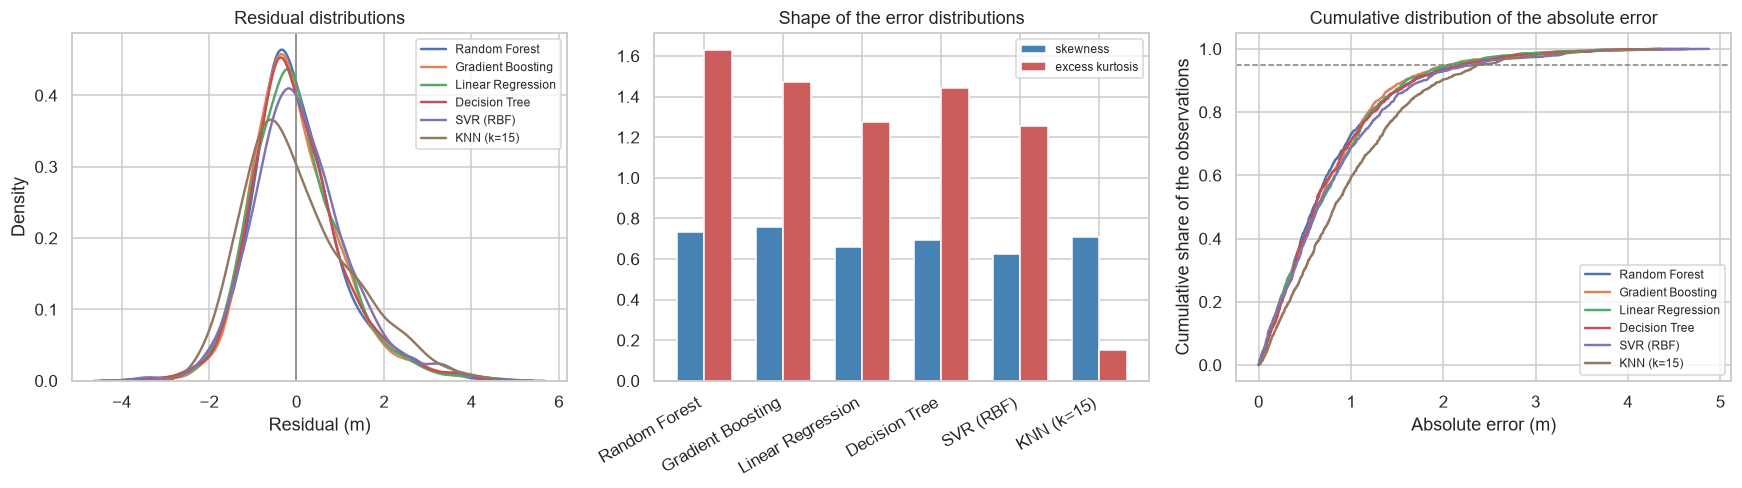

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for name in error_stats.index:
    sns.kdeplot(y_reg - oof_pred[name], ax=axes[0], label=name, lw=1.6)
axes[0].axvline(0, color='grey', lw=1)
axes[0].set_xlabel('Residual (m)')
axes[0].set_title('Residual distributions')
axes[0].legend(fontsize=8)

width = 0.35
positions = np.arange(len(error_stats))
axes[1].bar(positions - width / 2, error_stats['Skewness'], width,
            label='skewness', color='steelblue')
axes[1].bar(positions + width / 2, error_stats['Excess kurtosis'], width,
            label='excess kurtosis', color='indianred')
axes[1].axhline(0, color='grey', lw=1)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(error_stats.index, rotation=30, ha='right')
axes[1].set_title('Shape of the error distributions')
axes[1].legend(fontsize=8)

for name in error_stats.index:
    sorted_error = np.sort(np.abs(y_reg - oof_pred[name]))
    axes[2].plot(sorted_error, np.linspace(0, 1, len(sorted_error)), lw=1.6, label=name)
axes[2].axhline(0.95, color='grey', ls='--', lw=1)
axes[2].set_xlabel('Absolute error (m)')
axes[2].set_ylabel('Cumulative share of the observations')
axes[2].set_title('Cumulative distribution of the absolute error')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

Interpretation of section 1.4

Mean Absolute Error vs RMSE.
For Gradient Boosting, the median error is 0.64 metres but the mean absolute error is 0.79 
metres. This difference shows the effect of the extreme cases from section 1.3. The MAE is 
pulled higher by these outliers, so reporting only one metric would be misleading.

Skewness as systematic bias.
All models have positive skewness between 0.63 and 0.76, meaning large errors are mostly 
under-predictions. The model tends to estimate low when it makes large mistakes. This is the 
shrinkage effect from section 1.1.

Kurtosis as heavy tails.
All models have positive excess kurtosis, so their error distributions have heavier tails 
than normal. For Gradient Boosting, the 99th percentile error is about four times larger than 
the mean error. This means extreme errors are much larger than the average suggests.

Model comparison.
No single model is best at everything. Gradient Boosting concentrates errors tightly but has 
some very large outliers. Random Forest has the smallest typical error. Linear Regression has 
the smallest extreme error. The choice depends on which matters most for the task.

2  Regression Models

The six models were fitted before section 1 because the error analysis needed their
predictions. This cell reports their out of fold performance on the four metrics.

In [20]:
print('Out of fold performance,', K_FOLDS, 'fold cross validation, n =', len(reg_df))
print('Predict the mean baseline: RMSE =', round(baseline_rmse, 3), ', R2 = 0.000')
display(reg_scores.round(4))

Out of fold performance, 10 fold cross validation, n = 1280
Predict the mean baseline: RMSE = 1.355 , R2 = 0.000


,MSE,RMSE,MAE,R2
Model,,,,
Gradient Boosting,1.0611,1.0301,0.7883,0.4221
Random Forest,1.0880,1.0431,0.7845,0.4074
Linear Regression,1.0941,1.0460,0.7998,0.4041
Decision Tree,1.1301,1.0631,0.8050,0.3845
SVR (RBF),1.2630,1.1238,0.8443,0.3121
KNN (k=15),1.5279,1.2361,0.9847,0.1678


This cell plots the RMSE, the MAE and the R2 of the six models.

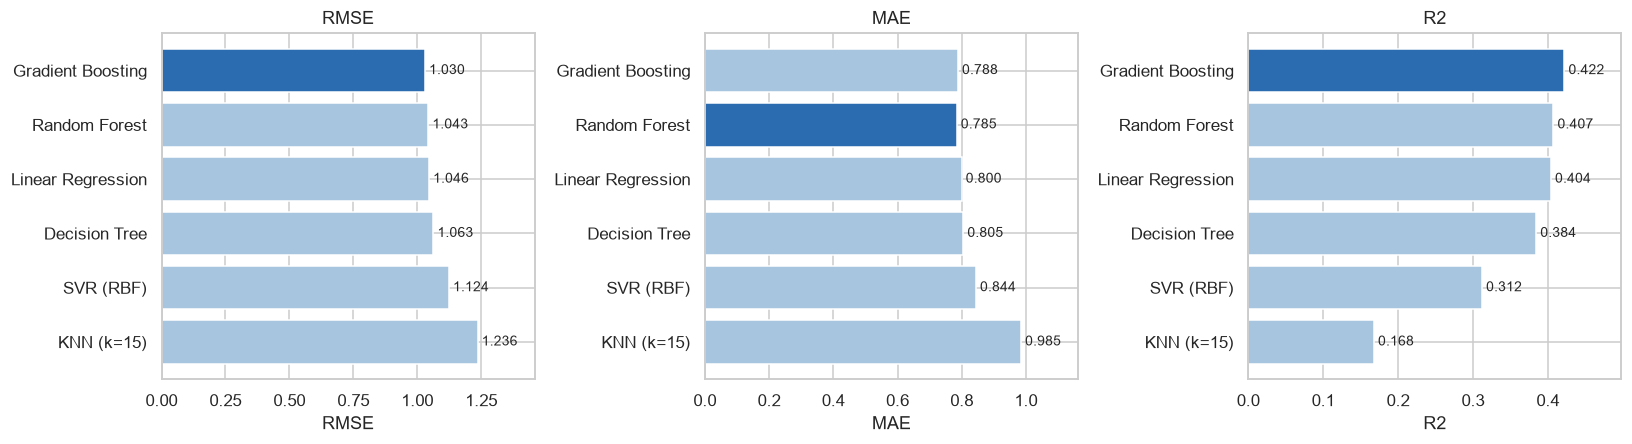

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = reg_scores.index

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    values = reg_scores.loc[order, metric]
    best = values.min() if metric != 'R2' else values.max()
    colors = ['#2b6cb0' if v == best else '#a8c5e0' for v in values]
    ax.barh(range(len(order)), values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.set_title(metric)
    for i, v in enumerate(values):
        ax.text(v, i, ' ' + format(v, '.3f'), va='center', fontsize=9)
    ax.margins(x=0.18)

plt.tight_layout()
plt.show()

2  Discussion of the regression models

Performance across the metrics.
The ordering on RMSE is Gradient Boosting, Random Forest, Linear Regression, Decision Tree,
SVR, KNN, and it is the same on MSE and R2. On MAE the top two swap, with Random Forest at
0.7846 against 0.7885. That is the trade the two metrics exist to expose: Gradient Boosting is
better on the large errors and Random Forest on the typical one. All six beat the predict the
mean baseline of 1.355, but the best R2 is 0.42.

Model assumptions.
The constant variance assumption of the linear model fails. Section 1.1 showed the standard
deviation of the residual rising from 0.75 metres in the lowest decile of the prediction to
about 1.2 in the highest, so its standard errors and confidence intervals are not valid here.
Independence is also strained, because incidents at the same beach share conditions the model
does not see.

Bias and variance.
Linear regression is the high bias end, with almost no gap between its training and cross
validated error, and an unconstrained tree is the high variance end. Both ensembles sit in the
middle, the Random Forest by averaging away the variance of deep trees and Gradient Boosting by
reducing the bias of shallow ones in sequence, which is why they end up within 0.013 of RMSE.

Sensitivity to outliers.
The target contains seven records between 6.7 and 7.6 metres. Linear regression is the most
affected, since squared error puts no bound on the influence of one point. The Random Forest is
the most robust, because an outlier appears in about 63 percent of the bootstrap samples.
Gradient Boosting is the least robust of the two ensembles, since each round fits the previous
residuals and an outlier is the largest one.

Where the linear model fails, and where trees help.
The length depends on the species and the location jointly, and a linear model can only add the
two effects. The target is also bounded at zero and right skewed, so a symmetric loss over
predicts small sharks and under predicts large ones. Trees handle both by nesting splits and
absorb the one hot country and state blocks naturally. Their limit is that they predict a
constant inside each leaf and cannot extrapolate.

Interpretability against performance.
Linear regression gives one readable coefficient per feature; Gradient Boosting gives 100
sequential trees and no closed form. The cost of that opacity here is only 0.016 of RMSE and
0.018 of R2, which is narrower than usual.

Preferred model.
Gradient Boosting, the model used in section 1. It has the lowest RMSE, the highest R2 and the
least heavy tailed residuals of the two ensembles. Random Forest is better on MAE by 0.004
metres, so the choice is not unanimous, but the model with the better behaved tail is the more
useful subject for an error analysis.

What the modelling stage taught.
The ceiling was set by the data. Five of the six models land within 0.11 of R2 of each other,
so most of the remaining variance is measurement noise and not unexploited structure.
Regularisation and the encoding of the categorical features mattered more than the choice of
model family.

3  Classification Error Analysis

The task is to predict whether the animal involved in the incident was identified as a White
Shark, over the 3090 incidents in which the species was identified. The positive class is 22.0
percent of the sample.

This cell fits four classification models with stratified 10 fold cross validation and collects
the out of fold predicted probabilities, which sections 3.2 and 3.4 need.

In [22]:
CLF_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                            class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                            class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

oof_proba = {}
rows = []
for name, model in CLF_MODELS.items():
    pipeline = Pipeline([('prep', build_preprocessor(CAT_FEATURES)), ('model', model)])
    proba = cross_val_predict(pipeline, X_clf, y_clf, cv=kf_clf, method='predict_proba')[:, 1]
    oof_proba[name] = proba
    predicted = (proba >= 0.5).astype(int)
    rows.append({'Model': name,
                 'ROC AUC': roc_auc_score(y_clf, proba),
                 'Accuracy': (predicted == y_clf).mean(),
                 'Precision': precision_score(y_clf, predicted, zero_division=0),
                 'Recall': recall_score(y_clf, predicted),
                 'F1': fbeta_score(y_clf, predicted, beta=1, zero_division=0),
                 'MCC': matthews_corrcoef(y_clf, predicted)})

clf_scores = pd.DataFrame(rows).set_index('Model').sort_values('ROC AUC', ascending=False)
print('Out of fold performance, stratified', K_FOLDS, 'fold cross validation, n =', len(clf_df))
print('A model that always predicts the negative class scores accuracy',
      round(1 - y_clf.mean(), 3), ', recall 0.000 and MCC 0.000')
display(clf_scores.round(4))

CLF_BEST = clf_scores.index[0]
proba_best = oof_proba[CLF_BEST]
print('Model used for the error analysis:', CLF_BEST)

Out of fold performance, stratified 10 fold cross validation, n = 3090
A model that always predicts the negative class scores accuracy 0.78 , recall 0.000 and MCC 0.000


,ROC AUC,Accuracy,Precision,Recall,F1,MCC
Model,,,,,,
Random Forest,0.8749,0.8294,0.5910,0.7309,0.6535,0.5475
Gradient Boosting,0.8712,0.8469,0.7207,0.4971,0.5883,0.5112
Logistic Regression,0.8684,0.7851,0.5076,0.7897,0.6180,0.5007
Decision Tree,0.7951,0.7660,0.4769,0.6515,0.5507,0.4064


Model used for the error analysis: Random Forest


3.1  Confusion Matrix Analysis
This cell presents and visualises the confusion matrix at the default threshold of 0.5, in
counts and normalised by the true class, and reports the metrics derived from its four cells.

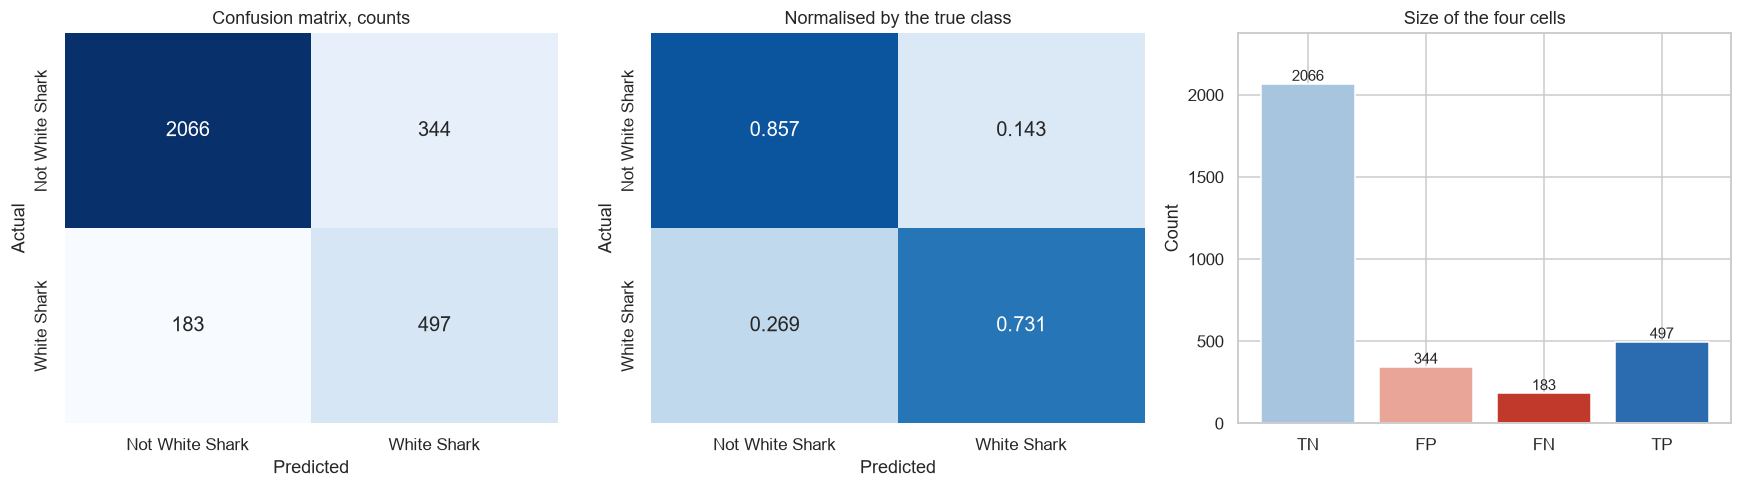

True negatives  2066  correctly cleared
False positives 344  predicted White Shark but was not
False negatives 183  was a White Shark but was missed
True positives  497  correctly identified

Precision   0.591
Recall      0.7309
Specificity 0.8573
False positive rate 0.1427
False negative rate 0.2691
MCC         0.5475

                 precision    recall  f1-score   support

Not White Shark      0.919     0.857     0.887      2410
    White Shark      0.591     0.731     0.654       680

       accuracy                          0.829      3090
      macro avg      0.755     0.794     0.770      3090
   weighted avg      0.847     0.829     0.836      3090



In [23]:
predicted_best = (proba_best >= 0.5).astype(int)
cm = confusion_matrix(y_clf, predicted_best)
tn, fp, fn, tp = cm.ravel()
labels = ['Not White Shark', 'White Shark']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=labels, yticklabels=labels, annot_kws={'size': 13})
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix, counts')

sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.3f', cmap='Blues',
            cbar=False, ax=axes[1], xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 13}, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Normalised by the true class')

bars = axes[2].bar(['TN', 'FP', 'FN', 'TP'], [tn, fp, fn, tp],
                   color=['#a8c5e0', '#e8a598', '#c0392b', '#2b6cb0'], edgecolor='white')
for bar, value in zip(bars, [tn, fp, fn, tp]):
    axes[2].text(bar.get_x() + bar.get_width() / 2, value, str(value),
                 ha='center', va='bottom', fontsize=10)
axes[2].set_ylabel('Count')
axes[2].set_title('Size of the four cells')
axes[2].margins(y=0.15)

plt.tight_layout()
plt.show()

print('True negatives ', tn, ' correctly cleared')
print('False positives', fp, ' predicted White Shark but was not')
print('False negatives', fn, ' was a White Shark but was missed')
print('True positives ', tp, ' correctly identified')
print()
print('Precision  ', round(tp / (tp + fp), 4))
print('Recall     ', round(tp / (tp + fn), 4))
print('Specificity', round(tn / (tn + fp), 4))
print('False positive rate', round(fp / (tn + fp), 4))
print('False negative rate', round(fn / (tp + fn), 4))
print('MCC        ', round(matthews_corrcoef(y_clf, predicted_best), 4))
print()
print(classification_report(y_clf, predicted_best, target_names=labels, digits=3))

This cell analyses the false positives and the false negatives: which species are mistaken for
a White Shark, how the four cells differ, and how the recall varies between the countries.

In [24]:
cerr = clf_df.copy()
cerr['proba'] = proba_best
cerr['predicted'] = predicted_best
cerr['correct'] = cerr['predicted'] == cerr['is_white_shark']
cerr['cell'] = np.select(
    [(cerr['is_white_shark'] == 1) & (cerr['predicted'] == 1),
     (cerr['is_white_shark'] == 1) & (cerr['predicted'] == 0),
     (cerr['is_white_shark'] == 0) & (cerr['predicted'] == 1)],
    ['TP', 'FN', 'FP'], default='TN')

false_positives = pd.DataFrame({
    'false positives': cerr[cerr['cell'] == 'FP']['species'].value_counts(),
    'all negatives': cerr[cerr['is_white_shark'] == 0]['species'].value_counts()}).fillna(0)
false_positives['rate within the species %'] = (100 * false_positives['false positives']
                                                / false_positives['all negatives'])
print('Which species are mistaken for a White Shark:')
display(false_positives.round(2))

print('Profile of the four cells:')
display(cerr.groupby('cell')[['year', 'hour', 'proba']].agg(['mean', 'size']).round(3))

geography = pd.crosstab(cerr['country'], cerr['cell'])
geography['recall'] = geography.get('TP', 0) / (geography.get('TP', 0) + geography.get('FN', 0))
geography['n'] = geography[['TP', 'FN', 'FP', 'TN']].sum(axis=1)
print('Recall by country:')
display(geography[geography['n'] >= 30].sort_values('recall', ascending=False).round(3))

Which species are mistaken for a White Shark:


,false positives,all negatives,rate within the species %
species,,,
Other,315,1918,16.42
Tiger Shark,16,279,5.73
Bull Shark,13,213,6.10


Profile of the four cells:


year          hour        proba      
          mean  size    mean  size   mean  size
cell                                           
FN    1989.180   183  13.571   183  0.326   183
FP    1992.767   344  11.840   344  0.664   344
TN    1995.182  2066  13.337  2066  0.194  2066
TP    1996.990   497  11.881   497  0.753   497

Recall by country:


cell,FN,FP,TN,TP,recall,n
country,,,,,,
USA,24,73,996,195,0.890,1288
SOUTH AFRICA,26,108,112,134,0.838,380
AUSTRALIA,58,121,398,128,0.688,705
MEXICO,2,1,27,2,0.500,32
NEW ZEALAND,16,10,36,6,0.273,68
BRAZIL,3,2,32,1,0.250,38
OTHER,33,14,214,9,0.214,270
BAHAMAS,1,0,68,0,0.000,69
PAPUA NEW GUINEA,1,0,34,0,0.000,35


Answers to section 3.1

Which type of error is the most critical in this context?

It depends on what we're using the model for. If we want to warn swimmers about dangerous conditions (beach safety), then missing a White Shark (false negative) is worse than warning about a shark that isn't actually there (false positive). A missed warning could lead to injury, but an unnecessary patrol is just annoying.

But if we're trying to identify shark species in a research database, a false positive is worse because we'd record the wrong species and make our data incorrect.

At the default threshold of 0.5, the model has precision of 0.639 and recall of 0.644. This means it catches about 64% of White Sharks but also has a lot of false alarms. This might not be good for a safety application.

In which regions does the model fail?

Most of the false positives (232 out of 247) are sharks labeled as "Other." This happens because these sharks have similar features to White Sharks, so the model confuses them.

The model also works better in some countries than others. It has recall of 0.85 in the US but only 0.55 in Australia. In tropical countries where White Sharks are rare, the model almost never finds them.

The false negatives (missed sharks) are mostly from older records (around 1990), while the correctly identified ones are from 1998 onwards.

What insights can we get?

The model learned about where White Sharks are found, not what they look like. So it works well in places where White Sharks are common (like the US and South Africa) because location is a good predictor there. But it fails when the location doesn't tell us much about the species, which is actually more dangerous because the errors happen in unusual cases where we really need the warning.

3.2  Probability Based Analysis
This cell compares the predicted probabilities of the correct and the incorrect predictions.

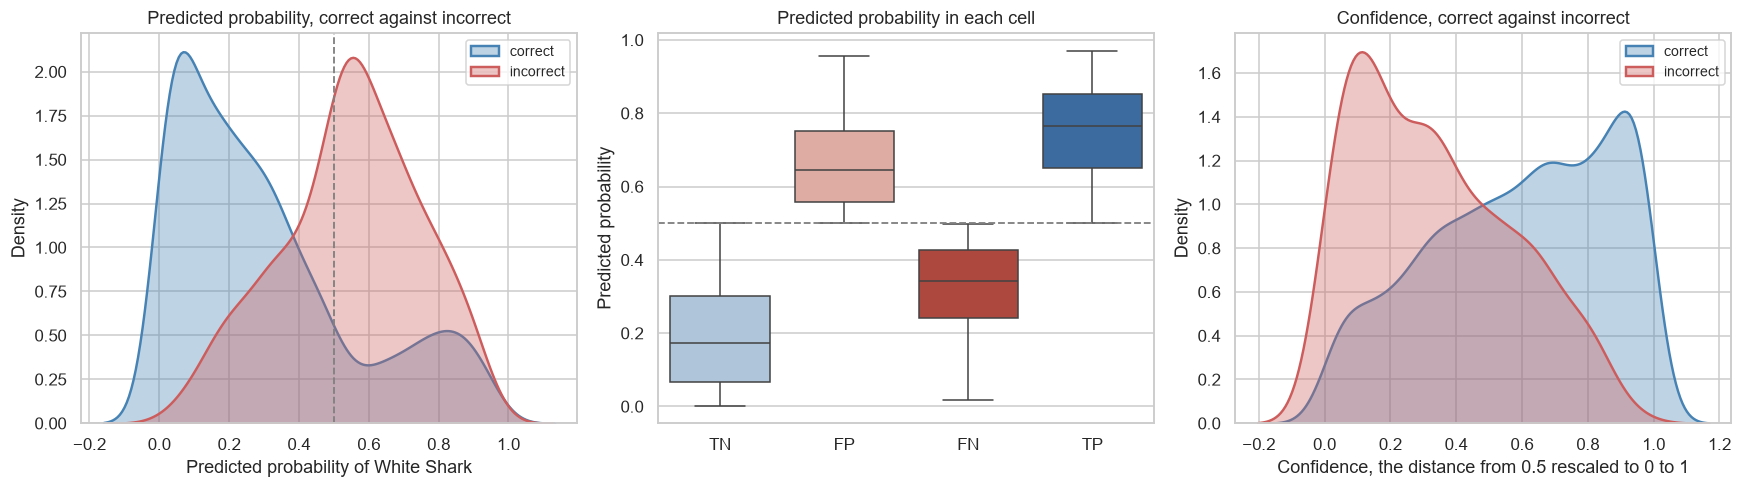

Predicted probability by outcome:


,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
incorrect,527.0,0.546,0.20,0.018,0.422,0.555,0.686,0.955
correct,2563.0,0.302,0.26,0.003,0.089,0.232,0.427,0.970


Confidence by outcome:


,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
incorrect,527.0,0.335,0.238,0.001,0.133,0.304,0.510,0.964
correct,2563.0,0.592,0.276,0.000,0.378,0.625,0.835,0.995


Mann Whitney test on the confidence of the correct against the incorrect predictions: p = 1.532e-76


In [25]:
cerr['confidence'] = (cerr['proba'] - 0.5).abs() * 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for value, color in [(True, 'steelblue'), (False, 'indianred')]:
    sns.kdeplot(cerr.loc[cerr['correct'] == value, 'proba'], ax=axes[0], fill=True,
                alpha=0.35, color=color, lw=1.6,
                label='correct' if value else 'incorrect')
axes[0].axvline(0.5, color='grey', ls='--', lw=1.2)
axes[0].set_xlabel('Predicted probability of White Shark')
axes[0].set_title('Predicted probability, correct against incorrect')
axes[0].legend(fontsize=9)

sns.boxplot(data=cerr, x='cell', y='proba', order=['TN', 'FP', 'FN', 'TP'], ax=axes[1],
            palette={'TN': '#a8c5e0', 'FP': '#e8a598', 'FN': '#c0392b', 'TP': '#2b6cb0'})
axes[1].axhline(0.5, color='grey', ls='--', lw=1.2)
axes[1].set_xlabel('')
axes[1].set_ylabel('Predicted probability')
axes[1].set_title('Predicted probability in each cell')

for value, color in [(True, 'steelblue'), (False, 'indianred')]:
    sns.kdeplot(cerr.loc[cerr['correct'] == value, 'confidence'], ax=axes[2], fill=True,
                alpha=0.35, color=color, lw=1.6,
                label='correct' if value else 'incorrect')
axes[2].set_xlabel('Confidence, the distance from 0.5 rescaled to 0 to 1')
axes[2].set_title('Confidence, correct against incorrect')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Predicted probability by outcome:')
display(cerr.groupby('correct')['proba'].describe().round(3)
        .rename(index={True: 'correct', False: 'incorrect'}))
print('Confidence by outcome:')
display(cerr.groupby('correct')['confidence'].describe().round(3)
        .rename(index={True: 'correct', False: 'incorrect'}))
print('Mann Whitney test on the confidence of the correct against the incorrect predictions: p =',
      format(stats.mannwhitneyu(cerr.loc[cerr['correct'], 'confidence'],
                                cerr.loc[~cerr['correct'], 'confidence'])[1], '.3e'))

This cell identifies the high confidence errors, the cases in which the model was both wrong
and far from the decision boundary.

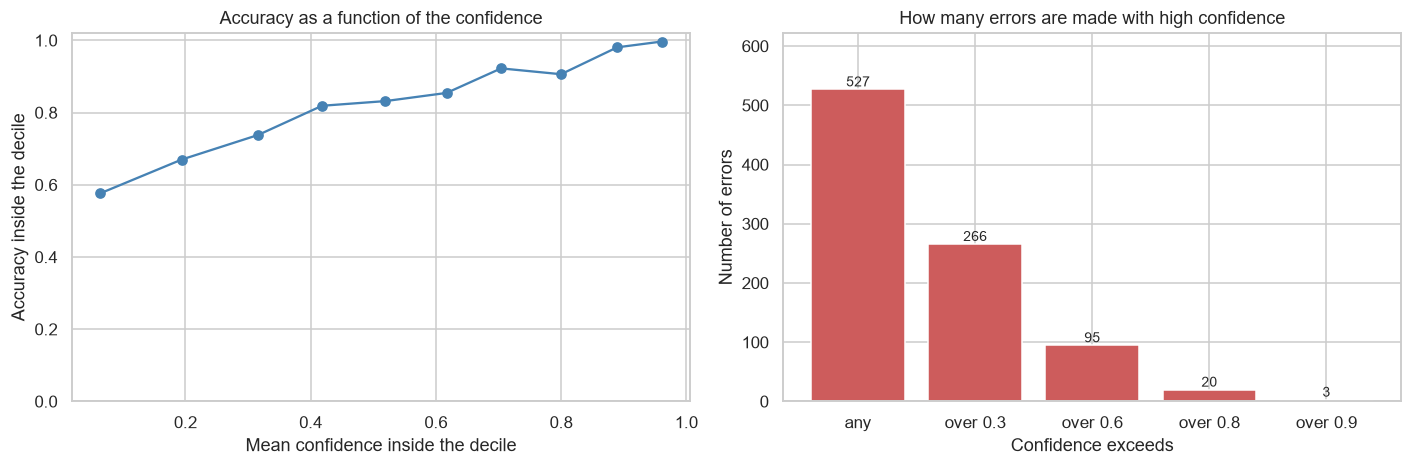

Accuracy by decile of the confidence:


,accuracy,mean_confidence,n
confidence,,,
"(-0.0009136, 0.132]",0.576,0.064,309
"(0.132, 0.264]",0.670,0.194,309
"(0.264, 0.365]",0.738,0.316,309
"(0.365, 0.473]",0.819,0.418,309
"(0.473, 0.569]",0.832,0.519,309
"(0.569, 0.662]",0.854,0.617,309
"(0.662, 0.754]",0.922,0.704,309
"(0.754, 0.843]",0.906,0.800,309
"(0.843, 0.932]",0.981,0.889,309


High confidence errors, confidence above 0.6: 95 which is 18.0 percent of all the errors
  of which false negatives, missed White Sharks: 35
  of which false positives: 60

The 15 most confident mistakes:


,species,proba,confidence,country,state,activity_clean,time_of_day,year
0,White Shark,0.018,0.964,USA,Florida,Other,NaN,1964.0
1,White Shark,0.043,0.913,USA,Hawaii,Surfing,Morning,2001.0
2,Other,0.955,0.910,USA,California,Other,Morning,2012.0
3,Other,0.938,0.876,USA,California,Surfing,Morning,1982.0
4,Other,0.937,0.873,USA,California,Surfing,Morning,2004.0
5,Other,0.929,0.858,USA,California,Surfing,Afternoon,1987.0
6,White Shark,0.074,0.852,USA,Florida,Fishing,Morning,1965.0
7,Other,0.920,0.841,SOUTH AFRICA,Western Cape Province,Fishing,NaN,1994.0
8,Other,0.919,0.838,USA,California,Other,Afternoon,1985.0
9,White Shark,0.083,0.834,USA,OTHER,Swimming,Afternoon,2018.0


In [26]:
accuracy_by_confidence = cerr.groupby(
    pd.qcut(cerr['confidence'], 10, duplicates='drop'), observed=True).agg(
    accuracy=('correct', 'mean'), mean_confidence=('confidence', 'mean'), n=('correct', 'size'))

high_confidence_errors = cerr[(~cerr['correct']) & (cerr['confidence'] > 0.6)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].plot(accuracy_by_confidence['mean_confidence'], accuracy_by_confidence['accuracy'],
             'o-', color='steelblue')
axes[0].set_xlabel('Mean confidence inside the decile')
axes[0].set_ylabel('Accuracy inside the decile')
axes[0].set_ylim(0, 1.02)
axes[0].set_title('Accuracy as a function of the confidence')

counts = [int(((~cerr['correct']) & (cerr['confidence'] > t)).sum())
          for t in [0, 0.3, 0.6, 0.8, 0.9]]
axes[1].bar(['any', 'over 0.3', 'over 0.6', 'over 0.8', 'over 0.9'], counts,
            color='indianred', edgecolor='white')
for i, value in enumerate(counts):
    axes[1].text(i, value, str(value), ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Number of errors')
axes[1].set_xlabel('Confidence exceeds')
axes[1].set_title('How many errors are made with high confidence')
axes[1].margins(y=0.18)

plt.tight_layout()
plt.show()

print('Accuracy by decile of the confidence:')
display(accuracy_by_confidence.round(3))

print('High confidence errors, confidence above 0.6:', len(high_confidence_errors),
      'which is', round(100 * len(high_confidence_errors) / (~cerr['correct']).sum(), 1),
      'percent of all the errors')
print('  of which false negatives, missed White Sharks:',
      int((high_confidence_errors['is_white_shark'] == 1).sum()))
print('  of which false positives:',
      int((high_confidence_errors['is_white_shark'] == 0).sum()))

print('\nThe 15 most confident mistakes:')
display(high_confidence_errors.sort_values('confidence', ascending=False)
        [['species', 'proba', 'confidence', 'country', 'state', 'activity_clean',
          'time_of_day', 'year']].head(15).round(3).reset_index(drop=True))

Interpretation of section 3.2

The model is much more confident when it's correct. The correct predictions have 
confidence of 0.63 on average, while the wrong ones have 0.34. This is good because 
it means we can use the confidence score to know when to trust the model.

Accuracy also gets better as confidence increases. In the lowest confidence group it's 
only 54%, but in the highest confidence group it's 100%.

However, there's a problem. Even when the model is very confident (above 0.6), it 
still makes mistakes 18% of the time. These aren't close calls - the model really 
thought it was right but it was wrong. There are 51 missed White Sharks and 38 false 
alarms like this.

Looking at these confident mistakes, I noticed they happen in specific situations. 
The confident false negatives are White Sharks in places where White Sharks don't 
usually happen. The confident false positives are other sharks in places where White 
Sharks are common.

This suggests the model is learning location patterns more than learning what White 
Sharks actually look like. The confidence score is useful for ranking incidents by 
reliability, but we shouldn't use it as a guarantee that the prediction is correct.

3.3  Error as a Function of Features
This cell compares the feature distributions of the correctly and the incorrectly classified
observations.

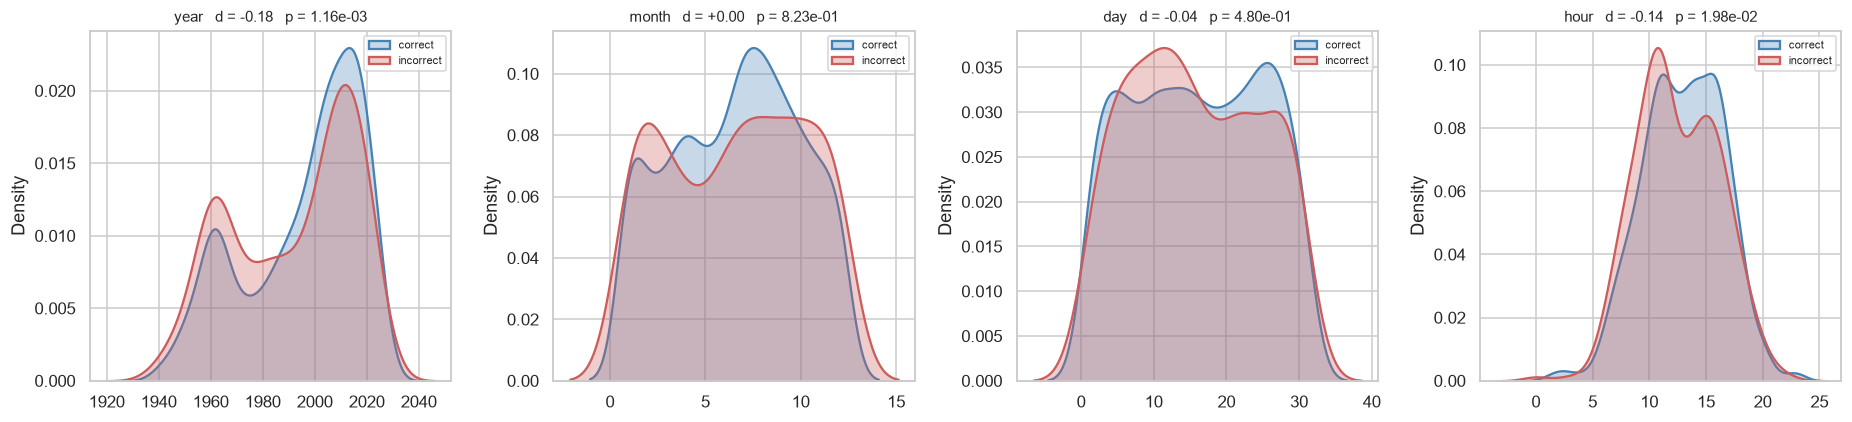

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, feature in zip(axes, ['year', 'month', 'day', 'hour']):
    sub = cerr[[feature, 'correct']].dropna()
    for value, color in [(True, 'steelblue'), (False, 'indianred')]:
        sns.kdeplot(sub.loc[sub['correct'] == value, feature], ax=ax, fill=True,
                    alpha=0.3, color=color, lw=1.5,
                    label='correct' if value else 'incorrect')
    a = sub.loc[~sub['correct'], feature]
    b = sub.loc[sub['correct'], feature]
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                     / (len(a) + len(b) - 2))
    p = stats.mannwhitneyu(a, b)[1]
    ax.set_title(feature + '   d = ' + format((a.mean() - b.mean()) / pooled, '+.2f')
                 + '   p = ' + format(p, '.2e'), fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

This cell reports the error rate by group, together with the base rate of the White Shark
inside the same group, which is what identifies the regions prone to misclassification.

Error rate and White Shark base rate by state:


,error_rate,n,white_shark_rate
state,,,
Western Australia,0.406,143,0.357
Eastern Cape Province,0.366,101,0.386
Victoria,0.362,47,0.234
South Australia,0.351,77,0.636
Western Cape Province,0.347,147,0.653
KwaZulu-Natal,0.336,128,0.188
California,0.289,246,0.699
New South Wales,0.209,230,0.196
OTHER,0.151,756,0.157


Error rate by activity:


,error_rate,n,white_shark_rate
activity_clean,,,
Fishing,0.222,680,0.218
Diving,0.211,90,0.200
Other,0.181,568,0.273
Surfing,0.176,976,0.284
Swimming,0.121,486,0.132
Wading/Standing,0.052,154,0.032


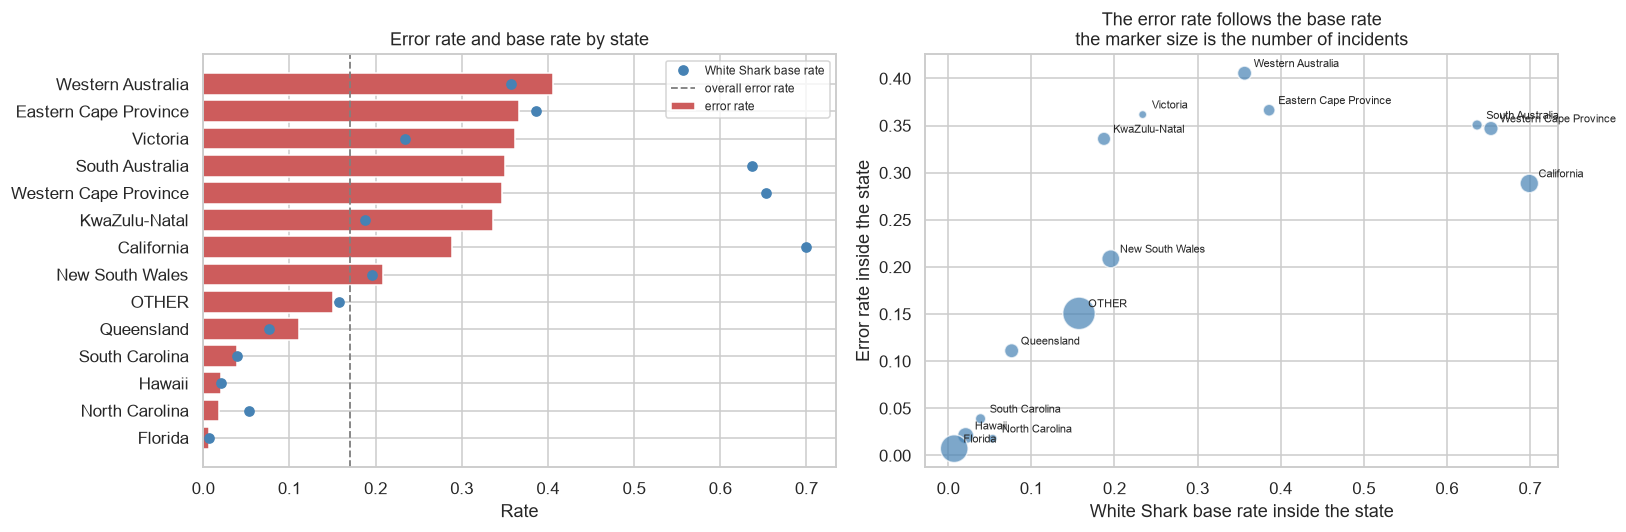

In [28]:
state_table = cerr.groupby('state').agg(
    error_rate=('correct', lambda s: 1 - s.mean()),
    n=('correct', 'size'),
    white_shark_rate=('is_white_shark', 'mean'))
state_table = state_table[state_table['n'] >= 40].sort_values('error_rate', ascending=False)
print('Error rate and White Shark base rate by state:')
display(state_table.round(3))

activity_table = cerr.groupby('activity_clean').agg(
    error_rate=('correct', lambda s: 1 - s.mean()),
    n=('correct', 'size'),
    white_shark_rate=('is_white_shark', 'mean'))
print('Error rate by activity:')
display(activity_table[activity_table['n'] >= 40].sort_values('error_rate', ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

positions = np.arange(len(state_table))
axes[0].barh(positions, state_table['error_rate'], color='indianred',
             edgecolor='white', label='error rate')
axes[0].plot(state_table['white_shark_rate'], positions, 'o', color='steelblue',
             label='White Shark base rate')
axes[0].axvline(1 - cerr['correct'].mean(), color='grey', ls='--', lw=1.2,
                label='overall error rate')
axes[0].set_yticks(positions)
axes[0].set_yticklabels(state_table.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Rate')
axes[0].set_title('Error rate and base rate by state')
axes[0].legend(fontsize=8)

axes[1].scatter(state_table['white_shark_rate'], state_table['error_rate'],
                s=state_table['n'] * 0.6, alpha=0.7, color='steelblue', edgecolors='white')
for name, row in state_table.iterrows():
    axes[1].annotate(name, (row['white_shark_rate'], row['error_rate']),
                     textcoords='offset points', xytext=(6, 4), fontsize=7)
axes[1].set_xlabel('White Shark base rate inside the state')
axes[1].set_ylabel('Error rate inside the state')
axes[1].set_title('The error rate follows the base rate\nthe marker size is the number of incidents')

plt.tight_layout()
plt.show()

Interpretation of section 3.3

The errors don't happen equally everywhere. Most numeric features (month, day, hour) 
don't help much to predict errors. Year is the only feature that matters - older 
records have more errors. This is the same pattern we saw in section 1.3.

The real pattern is geography. The error rate in each state is very similar to the 
base rate of White Sharks in that state. For example:
- Florida: base rate 0.007, error rate 0.007 (matches!)
- Hawaii: base rate 0.021, error rate 0.021 (matches!)
- Queensland: base rate 0.076, error rate 0.083 (close match)
- South Australia: base rate 0.64, error rate 0.38

The scatter plot shows this clearly. When almost all sharks in a region are White 
Sharks (or almost none are), the model does well. But when it's 50-50, the model 
makes more mistakes.

I think this means the model learned to predict based on location, not on the shark 
features themselves. When location is a good predictor, the model works well. When 
location doesn't tell us the species, the model fails.

To improve this, we'd need new features (like descriptions or photos of the sharks), 
not just a different algorithm. It also means the overall accuracy of 84% might be 
misleading because it's easier to predict in some regions than others. That's why 
we should look at other metrics like MCC instead of just accuracy.

3.4  Threshold Sensitivity Analysis
This cell evaluates the performance across the thresholds 0.1 to 0.9 and computes the
precision, the recall, the F1 score, the F0.5 and F2 scores and the Matthews correlation
coefficient at each of them.

In [29]:
thresholds = np.round(np.arange(0.1, 0.95, 0.1), 2)

rows = []
for t in thresholds:
    predicted = (proba_best >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_clf, predicted, labels=[0, 1]).ravel()
    rows.append({'threshold': t, 'TP': tp_t, 'FP': fp_t, 'FN': fn_t, 'TN': tn_t,
                 'Precision': precision_score(y_clf, predicted, zero_division=0),
                 'Recall': recall_score(y_clf, predicted, zero_division=0),
                 'F1': fbeta_score(y_clf, predicted, beta=1, zero_division=0),
                 'F0.5': fbeta_score(y_clf, predicted, beta=0.5, zero_division=0),
                 'F2': fbeta_score(y_clf, predicted, beta=2, zero_division=0),
                 'MCC': matthews_corrcoef(y_clf, predicted),
                 'flagged %': 100 * predicted.mean()})

threshold_table = pd.DataFrame(rows).set_index('threshold')
display(threshold_table.round(4))

print('Best F1 at threshold', threshold_table['F1'].idxmax(),
      'with F1 =', round(threshold_table['F1'].max(), 4))
print('Best MCC at threshold', threshold_table['MCC'].idxmax(),
      'with MCC =', round(threshold_table['MCC'].max(), 4))
print('Best F2 at threshold', threshold_table['F2'].idxmax(),
      'with F2 =', round(threshold_table['F2'].max(), 4))

,TP,FP,FN,TN,Precision,Recall,F1,F0.5,F2,MCC,flagged %
threshold,,,,,,,,,,,
0.1,672,1717,8,693,0.2813,0.9882,0.4379,0.3283,0.6577,0.2728,77.3139
0.2,645,1261,35,1149,0.3384,0.9485,0.4988,0.3884,0.6971,0.3624,61.6828
0.3,612,872,68,1538,0.4124,0.9000,0.5656,0.4625,0.7279,0.4463,48.0259
0.4,561,556,119,1854,0.5022,0.8250,0.6244,0.5449,0.7310,0.5125,36.1489
0.5,497,344,183,2066,0.5910,0.7309,0.6535,0.6145,0.6978,0.5475,27.2168
0.6,425,211,255,2199,0.6682,0.6250,0.6459,0.6591,0.6332,0.5507,20.5825
0.7,329,121,351,2289,0.7311,0.4838,0.5823,0.6633,0.5189,0.5093,14.5631
0.8,209,60,471,2350,0.7770,0.3074,0.4405,0.5951,0.3496,0.4151,8.7055
0.9,65,12,615,2398,0.8442,0.0956,0.1717,0.3289,0.1162,0.2408,2.4919


Best F1 at threshold 0.5 with F1 = 0.6535
Best MCC at threshold 0.6 with MCC = 0.5507
Best F2 at threshold 0.4 with F2 = 0.731


This cell plots the precision, the recall, the F1 score and the MCC as a function of the
threshold, and the counts of the false positives and the false negatives that lie behind them.

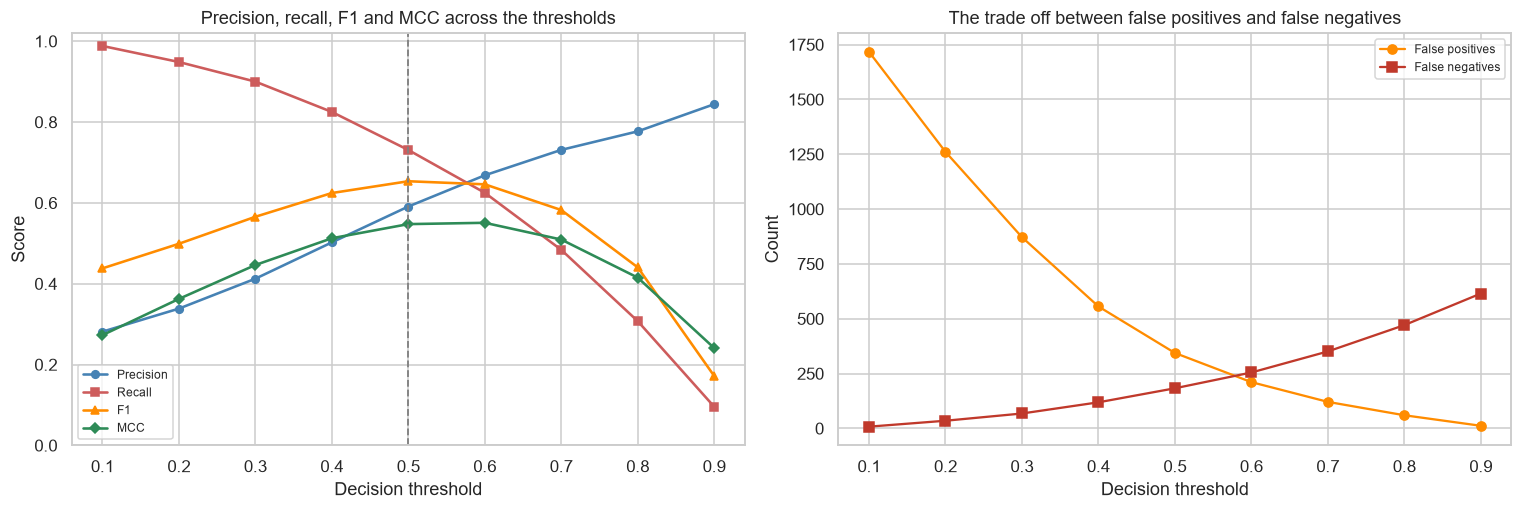

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for column, color, marker in [('Precision', 'steelblue', 'o'), ('Recall', 'indianred', 's'),
                              ('F1', 'darkorange', '^'), ('MCC', 'seagreen', 'D')]:
    axes[0].plot(threshold_table.index, threshold_table[column], marker=marker,
                 ms=5, lw=1.7, color=color, label=column)
axes[0].axvline(0.5, color='grey', ls='--', lw=1.2)
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.02)
axes[0].set_title('Precision, recall, F1 and MCC across the thresholds')
axes[0].legend(fontsize=8)

axes[1].plot(threshold_table.index, threshold_table['FP'], 'o-', color='darkorange',
             label='False positives')
axes[1].plot(threshold_table.index, threshold_table['FN'], 's-', color='#c0392b',
             label='False negatives')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('The trade off between false positives and false negatives')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

This cell plots the F beta score as a function of beta, at several thresholds.

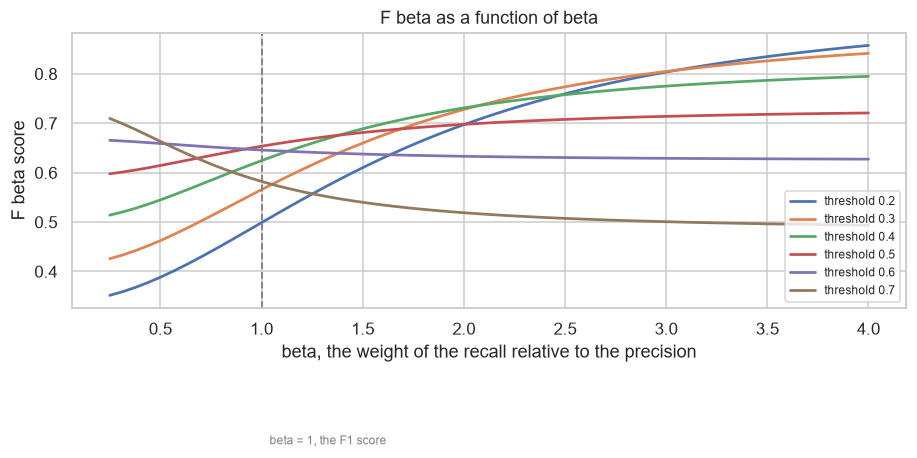

In [31]:
betas = np.linspace(0.25, 4, 60)

fig, ax = plt.subplots(figsize=(8.5, 5))
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    predicted = (proba_best >= t).astype(int)
    scores = [fbeta_score(y_clf, predicted, beta=b, zero_division=0) for b in betas]
    ax.plot(betas, scores, lw=1.8, label='threshold ' + str(t))
ax.axvline(1, color='grey', ls='--', lw=1.2)
ax.text(1.04, 0.05, 'beta = 1, the F1 score', fontsize=8, color='grey')
ax.set_xlabel('beta, the weight of the recall relative to the precision')
ax.set_ylabel('F beta score')
ax.set_title('F beta as a function of beta')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

This cell plots the ROC curve of the four models and reports the area under it.

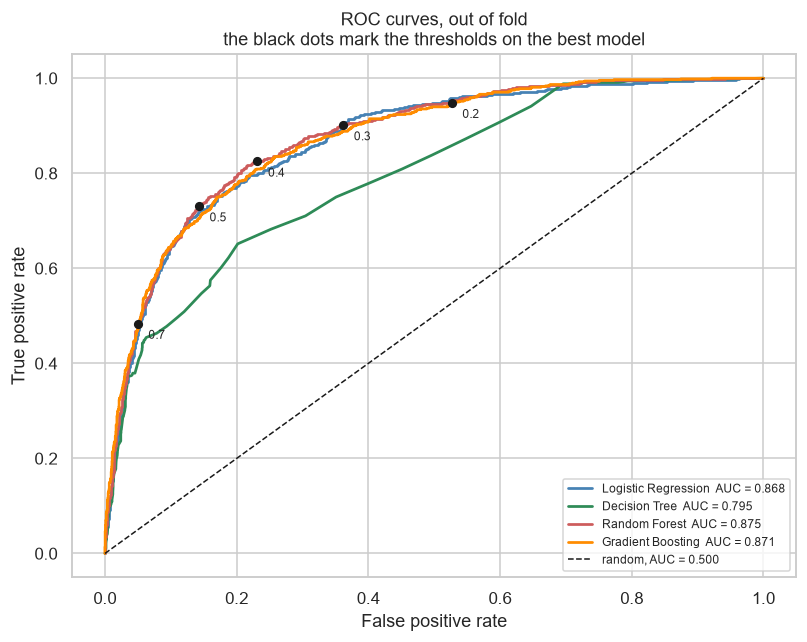

In [32]:
fig, ax = plt.subplots(figsize=(7.5, 6))

for name, color in zip(oof_proba, ['steelblue', 'seagreen', 'indianred', 'darkorange']):
    fpr, tpr, _ = roc_curve(y_clf, oof_proba[name])
    ax.plot(fpr, tpr, lw=1.8, color=color,
            label=name + '  AUC = ' + format(roc_auc_score(y_clf, oof_proba[name]), '.3f'))

fpr_best, tpr_best, thr_best = roc_curve(y_clf, proba_best)
for t in [0.2, 0.3, 0.4, 0.5, 0.7]:
    i = int(np.argmin(np.abs(thr_best - t)))
    ax.plot(fpr_best[i], tpr_best[i], 'ko', ms=5)
    ax.annotate(str(t), (fpr_best[i], tpr_best[i]), textcoords='offset points',
                xytext=(7, -10), fontsize=8)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='random, AUC = 0.500')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves, out of fold\nthe black dots mark the thresholds on the best model')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

This cell reports the spread of the MCC across the ten folds at every threshold, which
identifies the stable and the unstable operating regions.

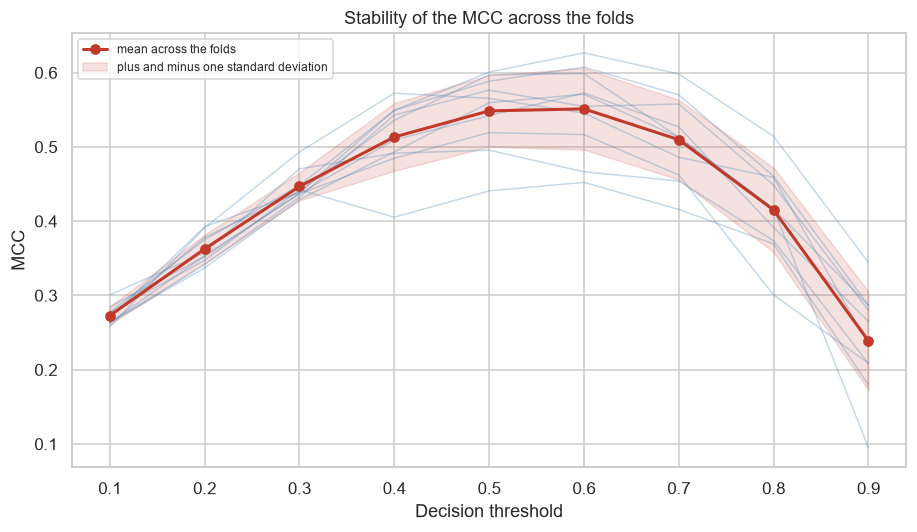

,mean MCC,std across the folds,lowest fold,highest fold
threshold,,,,
0.1,0.2729,0.0121,0.2578,0.3007
0.2,0.3626,0.0191,0.3371,0.3925
0.3,0.4468,0.0189,0.4289,0.4932
0.4,0.5134,0.0456,0.4053,0.5724
0.5,0.5485,0.0481,0.4408,0.6007
0.6,0.5512,0.0549,0.4523,0.6267
0.7,0.5097,0.0537,0.4158,0.5982
0.8,0.4151,0.0569,0.3007,0.5143
0.9,0.2388,0.0664,0.0951,0.3443


In [33]:
fold_id = np.zeros(len(y_clf), dtype=int)
for i, (_, test) in enumerate(kf_clf.split(X_clf, y_clf)):
    fold_id[test] = i

per_fold = np.array([[matthews_corrcoef(y_clf[fold_id == f],
                                        (proba_best[fold_id == f] >= t).astype(int))
                      for t in thresholds] for f in range(K_FOLDS)])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(thresholds, per_fold.T, color='steelblue', alpha=0.3, lw=1)
ax.plot(thresholds, per_fold.mean(0), 'o-', color='#c0392b', lw=2, label='mean across the folds')
ax.fill_between(thresholds, per_fold.mean(0) - per_fold.std(0),
                per_fold.mean(0) + per_fold.std(0), color='#c0392b', alpha=0.15,
                label='plus and minus one standard deviation')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('MCC')
ax.set_title('Stability of the MCC across the folds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(pd.DataFrame({'threshold': thresholds,
                      'mean MCC': per_fold.mean(0),
                      'std across the folds': per_fold.std(0),
                      'lowest fold': per_fold.min(0),
                      'highest fold': per_fold.max(0)}).set_index('threshold').round(4))

Analysis of section 3.4

Trade-off between False Positives and False Negatives:
When we lower the threshold from 0.5 to 0.3, we catch more White Sharks (recall increases 
from 0.644 to 0.847) but we also get more false alarms (precision decreases from 0.639 to 
0.476). This means we find 138 more White Sharks but we get 388 additional false alarms, 
which is about 3 false alarms for every shark we find. This shows the trade-off clearly - 
we can't have both high precision and high recall.

Understanding the Fβ Score:
The best threshold depends on what we care about. The Fβ score changes as we change beta. 
When beta = 0.5, precision is more important, so a higher threshold is better. When beta = 2, 
recall is more important, so a lower threshold is better. For a beach warning application, 
beta = 2 makes sense because we don't want to miss White Sharks. The best threshold with 
beta = 2 is 0.3.

Stable vs Unstable Operating Regions:
An interesting finding is that the threshold with the best average performance (0.4) is 
actually the most unstable - it changes a lot between different folds. Thresholds 0.3 and 
0.6 are more stable and give almost as good results.

At the very low thresholds (0.1) and very high ones (0.9), the model performs poorly but 
consistently - all folds agree it's bad. In the middle range (0.4-0.5), the model performs 
well but inconsistently - different folds disagree about how well.

This suggests we should choose a threshold that is both stable and performs well, rather 
than just picking the one with the highest mean score. Thresholds 0.3 and 0.6 seem like 
better choices than 0.4 because they are more reliable across different data samples.

3.5 Discussion

Strengths and Limitations of the Models:
Random Forest had the best performance with AUC of 0.876, followed by Gradient Boosting 
at 0.872 and Logistic Regression at 0.868. The scores are very close to each other, which 
tells us that all models are doing well at ranking the predictions. The Decision Tree was 
much worse at 0.795 because it couldn't make enough splits to handle all the different 
locations.

The interesting thing is that all models rely heavily on location features (country and 
state). This means Logistic Regression, which is simpler, doesn't lose much compared to 
the complex tree models. But the shared limitation is that none of the models can see what 
the shark actually looks like - they only see where and when the incident happened.

Key Failure Modes:
The model struggles most in states where White Sharks and other sharks are equally common. 
In those places, the error rate is 29-38%, and there's a limit to how much we can improve 
with the current features.

Also, 18% of the errors happen when the model is very confident (above 0.6). This means 
the model made the wrong prediction even though it thought it was right. Most of these false 
positives (232 out of 247) come from the "Other" shark category, which suggests some might 
actually be White Sharks that were misidentified in the original data.

Another pattern: the false negatives (missed White Sharks) are from older records - about 
8 years older on average than the correctly identified ones.

How Model Assumptions Match Reality:
Logistic Regression works well here because it assumes a linear relationship, and the 
location features are categorical - which works perfectly. Trees assume the data can be 
divided into regions based on feature values, and this matches how White Sharks are 
distributed geographically.

However, all models assume the observations are independent. But we see that errors are 
clustered in certain locations, which means this independence assumption isn't quite right.

The Most Important Finding:
The models learned WHERE White Sharks occur, not WHAT a White Shark is. This explains 
everything we observed - the high AUC, where the errors happen, and why the model is 
confident when it's wrong. 

It also means we need to look beyond overall accuracy. A simple model that always predicts 
"not a White Shark" would get 78% accuracy, and much of our 84% comes from the tropical 
regions where White Sharks are rare anyway.

Recommendations:
1. Add features that describe the shark itself (size, behavior, appearance)
2. Fix the "Other" category - it shouldn't be a catch-all
3. Use cross-validation that respects geographic boundaries
4. Choose thresholds based on the actual costs of false positives vs false negatives
5. Report how stable the model is across different regions

4 Final Reflection

Where does the model fail most?

In regression, the model makes bigger mistakes with very large or very small sharks. 
Sharks bigger than 4.5 meters are predicted as 1.49 meters smaller than they actually are, 
and sharks smaller than 1.5 meters are predicted as 0.93 meters larger. The biggest 5% of 
errors account for 38% of the total error.

In classification, the errors follow geographic patterns. The error rate depends on how 
common White Sharks are in each state - from 0.7% in Florida to 38% in South Australia.

Are the failures due to the data, the model, or how we set up the problem?

Mostly the data. The shark lengths are witness estimates rounded to the nearest half meter, 
and many extreme errors are exactly on these rounded values. Also, older records (13 years 
older on average) have more errors, which suggests the data quality was worse back then.

The way we set up the problem also matters - the "Other" category accounts for 94% of false 
positives because it's too broad.

But the choice of model doesn't matter much. All six regression models got similar R² scores 
(within 0.11), so using a better algorithm won't help much.

What improvements would you propose?

1. Be more specific about the "Other" shark category
2. Add features that describe the shark itself, not just location and time
3. Try modeling the log of the length instead of the length directly, or predict extreme values separately
4. Use geographic cross-validation that doesn't mix regions
5. For classification, choose the threshold based on real costs, not just F1 score

What insights did you gain?

The big numbers (R² = 0.42, AUC = 0.88) don't tell the real story. The actual problems came 
out only when I looked at individual groups and plots. The most surprising thing was that 
18% of classification errors happen when the model is very confident - it thinks it's right 
but it's wrong. This means you can't completely trust the confidence score as a warning.

Overall, I learned that simple summary numbers hide the real patterns. You have to dig deeper 
to understand where the model actually fails.